Rule based and Transformation Based Learning Rule-Based NLP

Rule-based NLP systems rely on manually created linguistic rules, patterns, and dictionaries to process language.

How it works: Define if–then rules for tokenization, POS tagging, parsing, or extracting meaning.

**Example:**

Rule: If a word ends with “-ed” → likely past tense verb.

Rule: If a sentence has the pattern **“How much is ___ ?”** → classify it as a price query.

**Pros:**

Transparent, explainable.

Good for small, well-defined tasks.

**Cons:**

Requires a lot of manual effort.

Doesn’t scale well to large or ambiguous datasets.

Struggles with exceptions and unseen patterns.

**Transformation-Based Learning (TBL)**

Definition: It’s a machine learning method for NLP that starts with a simple baseline model and then applies learned transformation rules to improve performance.

How it works:

Start with an initial guess (baseline).

Example: Assign the most common POS tag for each word (e.g., “book” = noun).

Learn transformation rules from training data that fix mistakes.

Rule: If the word is **“book” and the next word is “a noun,” then change tag from noun → verb.**

Apply rules iteratively to improve accuracy.

**Example**

Transformation rule (learned): If a word ends with** “-ing” → **change from noun to verb.

**Pros:**

Combines interpretability of rules with data-driven learning.

Rules are human-readable and linguistically meaningful.

**Cons:**

Training can be slower compared to statistical models.

Outperformed today by deep learning approaches, but still useful for understanding hybrid rule+learning systems.

**✅ Key Difference:**

Rule-based → Hand-crafted rules only.

Transformation-based learning → Learns rules automatically from data to improve an initial baseline.
************************************************************************

**📘 Rule-Based Example**

Task: Identify if a sentence is a question.

Rules:

If a sentence ends with "?" → classify as Question.

If a sentence starts with words like Who, What, When, Where, Why, How → classify as Question.

Otherwise → classify as Statement.

**Example Sentences**

"What is your name?" → Rule 2 applies → Question ✅

"This is my book." → No rule applies → Statement ✅

"Are you coming?" → Rule 1 applies → Question ✅

In [ ]:
# Example sentences
sentences = [
    "What is your name",
    "This is my book.",
    "Are you coming?",
    "I love natural language processing."
]

# Rule-based classification
for sentence in sentences:
    if sentence.strip().endswith("?"):
        label = "Question"
    elif sentence.strip().split()[0].lower() in ["who", "what", "when", "where", "why", "how"]:
        label = "Question"
    else:
        label = "Statement"

    print(sentence, "-->", label)


What is your name --> Question
This is my book. --> Statement
Are you coming? --> Question
I love natural language processing. --> Statement


In [ ]:
# Example sentences
sentences = [
    "I love this product, it is amazing!",
    "This movie is terrible and boring.",
    "The food was good but the service was bad.",
    "I dont love dogs",
    "I am happy with my new phone.",
    "The laptop is slow and awful."
]

# Define rule-based word lists
positive_words = ["love", "good", "happy", "amazing", "great"]
negative_words = ["bad", "terrible", "boring", "awful", "slow"]

# Apply rules
for sentence in sentences:
    text = sentence.lower()

    if any(word in text for word in positive_words):
        label = "Positive"
    elif any(word in text for word in negative_words):
        label = "Negative"
    else:
        label = "Neutral"

    print(sentence, "-->", label)


I love this product, it is amazing! --> Positive
This movie is terrible and boring. --> Negative
The food was good but the service was bad. --> Positive
I dont love dogs --> Positive
I am happy with my new phone. --> Positive
The laptop is slow and awful. --> Negative


In [ ]:
# Example sentences
sentences = [
    "Barack Obama was born in Hawaii.",
    "I met John yesterday.",
    "The conference will be held in New York on 21st September.",
    "Amazon is a big company.",
]

# Apply simple rules
for sentence in sentences:
    words = sentence.split()
    entities = []

    for word in words:
        # Rule 1: If word is capitalized and not at sentence start -> assume it's a NAME/PLACE
        if word[0].isupper() and word.lower() not in ["i", "The"]:
            entities.append((word, "Name/Place"))

        # Rule 2: If word looks like a date/number
        elif word.isdigit() or word.endswith("st") or word.endswith("th"):
            entities.append((word, "Date"))

    print(sentence)
    print("Entities found:", entities)
    print("-" * 50)


Barack Obama was born in Hawaii.
Entities found: [('Barack', 'Name/Place'), ('Obama', 'Name/Place'), ('Hawaii.', 'Name/Place')]
--------------------------------------------------
I met John yesterday.
Entities found: [('John', 'Name/Place')]
--------------------------------------------------
The conference will be held in New York on 21st September.
Entities found: [('The', 'Name/Place'), ('New', 'Name/Place'), ('York', 'Name/Place'), ('21st', 'Date'), ('September.', 'Name/Place')]
--------------------------------------------------
Amazon is a big company.
Entities found: [('Amazon', 'Name/Place')]
--------------------------------------------------


In [ ]:
sentences = [
    "John was born in Hawaii.",
    "I met John yesterday.",
    "He is going to the market.",
]

# Step 1: Detect the first capitalized word from the first sentence
first_sentence_words = sentences[0].split()
replacement_name = None

for word in first_sentence_words:
    if word[0].isupper():
        replacement_name = word
        break

# Step 2: Replace standalone capitalized words in later sentences
for sentence in sentences:
    words = sentence.split()
    new_words = []

    for word in words:
        # Rule: If a word starts with capital and is not the chosen name, replace it
        if word[0].isupper() and word != replacement_name:
            new_words.append(replacement_name)
        else:
            new_words.append(word)

    new_sentence = " ".join(new_words)
    print("Original:", sentence)
    print("Modified:", new_sentence)
    print("-" * 50)


Original: John was born in Hawaii.
Modified: John was born in John
--------------------------------------------------
Original: I met John yesterday.
Modified: John met John yesterday.
--------------------------------------------------
Original: He is going to the market.
Modified: John is going to the market.
--------------------------------------------------


In [ ]:
import re

sentences = [
    "I am John. John was born in Hawaii. I am going to the market.",
    "Meera is from India. She likes to read books."
]

for paragraph in sentences:
    tokens = paragraph.split()
    counts = {}
    first_index = {}

    # Collect candidate capitalized words (skip single-letter 'I' here)
    for i, token in enumerate(tokens):
        # strip leading/trailing non-letters
        clean = re.sub(r'^[^A-Za-z]+|[^A-Za-z]+$', '', token)
        if clean and clean[0].isupper() and len(clean) > 1 and clean.isalpha():
            counts[clean] = counts.get(clean, 0) + 1
            if clean not in first_index:
                first_index[clean] = i

    replacement_name = None
    if counts:
        # choose the most frequent capitalized word; tie -> earliest occurrence
        replacement_name = max(counts.items(), key=lambda kv: (kv[1], -first_index[kv[0]]))[0]

    # Replace short uppercase words (heuristic: length <= 3) with the replacement_name
    new_tokens = []
    for token in tokens:
        m = re.match(r'^([^A-Za-z]*)([A-Za-z]+)([^A-Za-z]*)$', token)
        if m:
            prefix, word, suffix = m.groups()
            if word[0].isupper() and replacement_name and word != replacement_name and len(word) <= 3:
                # preserve surrounding punctuation
                new_token = prefix + replacement_name + suffix
            else:
                new_token = token
        else:
            new_token = token
        new_tokens.append(new_token)

    new_paragraph = " ".join(new_tokens)

    # Small grammar cleanups (optional but useful)
    if replacement_name:
        # "John am" -> "John is"
        new_paragraph = re.sub(r'\b' + re.escape(replacement_name) + r'\s+am\b', replacement_name + ' is', new_paragraph)
        # "John is John" -> "John"
        new_paragraph = re.sub(r'\b' + re.escape(replacement_name) + r'\s+is\s+' + re.escape(replacement_name) + r'\b', replacement_name, new_paragraph)

    print("Original:", paragraph)
    print("Modified:", new_paragraph)
    print("-" * 50)


Original: I am John. John was born in Hawaii. I am going to the market.
Modified: John. John was born in Hawaii. John is going to the market.
--------------------------------------------------
Original: Meera is from India. She likes to read books.
Modified: Meera is from India. Meera likes to read books.
--------------------------------------------------


In [ ]:
import re

#Return a list containing every occurrence of "ai":

txt = "The rain in Spain"
x = re.findall("ai", txt)
print(x)


['ai', 'ai']


In [ ]:
import re

txt = "The rain in Spain"
x = re.findall("Portugal", txt)
print(x)

[]


In [ ]:
import re

text = "Contact us at support@example.com or sales@my-shop.org."
pattern = r"[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}"

emails = re.findall(pattern, text)
print(emails)


['support@example.com', 'sales@my-shop.org']


In [ ]:
import re

text = "Contact us at support@example.com or sales@my-shop.org."
pattern = r"[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.com"

emails = re.findall(pattern, text)
print(emails)

['support@example.com']


In [ ]:
import re

text = "I have 2 cats, 12 dogs, and 1 turtle."
pattern = r"\d+"

numbers = re.findall(pattern, text)
print(numbers)

['2', '12', '1']


In [ ]:
import re

text = "I have 2 cats, 12 dogs, and 1 turtle."

# search looks for the FIRST match
match = re.search(r"cat", text)

if match:
    print("Found:", match.group())
else:
    print("Not found")


Found: cat


In [ ]:
import re

text = "I have 12 apples and 5 oranges."

# re.search
search_result = re.search(r'\d+', text)
print(search_result.group())  # Output: 12

# re.findall
findall_result = re.findall(r'\d+', text)
print(findall_result)         # Output: ['12', '5']


12
['12', '5']


In [ ]:
import re

text = "apple,banana,orange"
result = re.split(r",", text)
print(result)


['apple', 'banana', 'orange']


In [ ]:
import re

text = "apple, banana;orange grape"
result = re.split(r"[ ,;]+", text)
print(result)


['apple', 'banana', 'orange', 'grape']


In [ ]:
import re

text = "item1item2item3"
result = re.split(r"\d+", text)
print(result)


['item', 'item', 'item', '']


**Transformation-Based Learning (TBL)**

TBL is a rule-based machine learning approach in NLP where a model iteratively improves a baseline prediction by applying learned transformation rules that correct mistakes.


How it Works

*  Assign initial guesses to your task (e.g., all words as nouns in POS tagging).

Example: "John runs fast" → John/NN runs/NN fast/NN

* Compare with correct output / Compare baseline tags with gold standard labels in training data.

*  Generate transformation rules and Identify patterns where the baseline is wrong.

*  Create rules to fix those errors.

**Example rules for POS tagging:**

Example: "John runs fast" → John/NN runs/NN fast/NN

*  If the previous word is "John" and current word is "runs", change tag from NN → VBZ.

*  If a word ends with "s", change NN → VBZ.

*  Apply rules iteratively

*  Apply the best rule that reduces the most errors.

*  Repeat until no more significant improvement is possible.

**Key Features**
*  Rule-based + machine learning
* Output	Sequence of transformation rules
*  Human-readable rules, interpretable, good for small data
*  Slower than modern ML, less flexible than deep learning

**Example Idea**

Task: POS tagging

Baseline: Tag all words as NN (noun)

**Learned Rules:**

"He" →  Personal pronoun

"runs" → 3rd person sing. present if previous word is a proper noun

"ing" ending →  Verb, gerund or present participle

Result: Baseline errors get corrected iteratively.

In [ ]:
# Sample sentences
sentences = [
    ["I", "saw", "the", "cat"],
    ["He", "likes", "the", "dog"]
]

# Baseline: tag everything as NN (noun)
baseline_tags = [["NN"] * len(sent) for sent in sentences]

# Function to apply simple transformation rules
def apply_rules(words, tags):
    for i, word in enumerate(words):
        # Rule 1: If the word is "I" or "He", tag as PRP (pronoun)
        if word in ["I", "He"]:
            tags[i] = "PRP"
        # Rule 2: If the previous word is "the", tag current word as NN (noun)
        if i > 0 and words[i-1] == "the":
            tags[i] = "NN"
        # Rule 3: If the word is "saw" or "likes" and previous word is pronoun, tag as VB (verb)
        if word in ["saw", "likes"] and i > 0 and tags[i-1] == "PRP":
            tags[i] = "VB"
    return tags

# Apply TBL
final_tags = []
for sent, tags in zip(sentences, baseline_tags):
    new_tags = apply_rules(sent, tags)
    final_tags.append(new_tags)

# Display results
for sent, tags in zip(sentences, final_tags):
    print(list(zip(sent, tags)))


[('I', 'PRP'), ('saw', 'VB'), ('the', 'NN'), ('cat', 'NN')]
[('He', 'PRP'), ('likes', 'VB'), ('the', 'NN'), ('dog', 'NN')]


In [ ]:
# Training data: (word, correct_tag)
training_data = [
    ("I", "PRP"),
    ("saw", "VB"),
    ("the", "DT"),
    ("cat", "NN")
]

# Baseline: predict all words as NN
baseline = [
    ("I", "NN"),
    ("saw", "NN"),
    ("the", "NN"),
    ("cat", "NN")
]

# Step 1: Learn transformations by comparing baseline to training data
transformations = []  # store (word, correct_tag)
for i in range(len(baseline)):
    word = baseline[i][0]
    predicted = baseline[i][1]
    correct = training_data[i][1]
    if predicted != correct:
        transformations.append((word, correct))

print("Learned transformations:", transformations)

# Step 2: Apply transformations to baseline
for i in range(len(baseline)):
    word, tag = baseline[i]
    for w, new_tag in transformations:
        if word == w:
            baseline[i] = (word, new_tag)

# Step 3: Show final output
for word, tag in baseline:
    print(word, "->", tag)


Learned transformations: [('I', 'PRP'), ('saw', 'VB'), ('the', 'DT')]
I -> PRP
saw -> VB
the -> DT
cat -> NN


**Hidden Markov Models**

60% chance the first day is Sunny

40% chance the first day is Rainy

In [ ]:
start_prob = {"Sunny": 0.6, "Rainy": 0.4}

1b. Transition probabilities

Probability of moving from one state to another:

In [ ]:
trans_prob = {
    "Sunny": {"Sunny": 0.7, "Rainy": 0.3},
    "Rainy": {"Sunny": 0.4, "Rainy": 0.6}
}


1️⃣ Emission Probabilities (Observation Probabilities)

In HMM terminology:

Hidden states: The things we cannot directly observe (here: weather = Sunny or Rainy).

Observations: The things we can see (here: Walk, Shop, Clean).

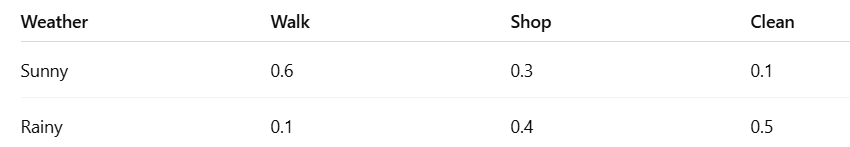
  

If it’s Sunny, most likely person Walks (0.6), less likely Shops (0.3), rarely Cleans (0.1).

If it’s Rainy, most likely Cleans (0.5), sometimes Shops (0.4), rarely Walks (0.1).

✅ So emission probabilities link hidden states to what we actually observe.


2️⃣ Observation Sequence

The observation sequence is the series of visible events that the HMM sees. We don’t know the hidden states (weather), but we know the observations.

In [ ]:
obs_seq = ["Walk", "Shop", "Clean"]

Day 1 → Walk

Day 2 → Shop

Day 3 → Clean

Purpose:

The observation sequence is input to the HMM.

The HMM uses it with start, transition, and emission probabilities to estimate the most likely hidden states sequence.

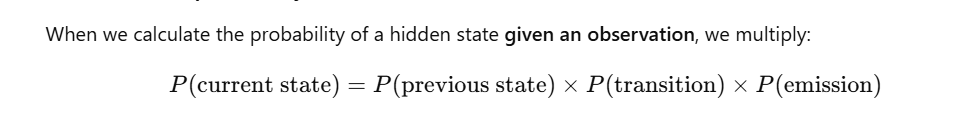

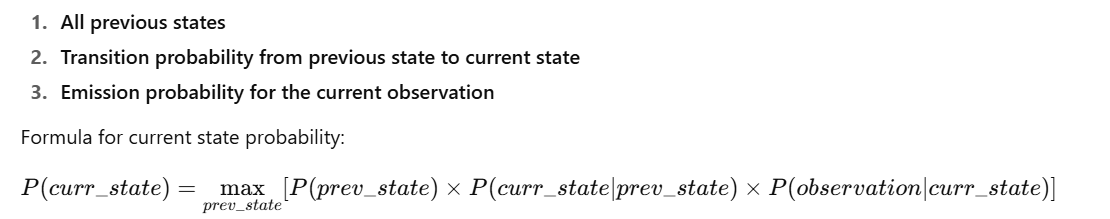

In [ ]:
# States
states = ["Sunny", "Rainy"]

# Observations
obs_seq = ["Walk", "Shop", "Clean"]

# Start probabilities
start_prob = {"Sunny": 0.6, "Rainy": 0.4}

# Transition probabilities
trans_prob = {
    "Sunny": {"Sunny": 0.7, "Rainy": 0.3},
    "Rainy": {"Sunny": 0.4, "Rainy": 0.6}
}

# Emission probabilities
emit_prob = {
    "Sunny": {"Walk": 0.6, "Shop": 0.3, "Clean": 0.1},
    "Rainy": {"Walk": 0.1, "Shop": 0.4, "Clean": 0.5}
}

# Step 0: initialize
V = [{}]   # probability table
path = {}  # path table

for state in states:
    V[0][state] = start_prob[state] * emit_prob[state][obs_seq[0]]
    path[state] = [state]

# Step 1..T
for t in range(1, len(obs_seq)):
    V.append({})
    new_path = {}
    for curr_state in states:
        # find the previous state that gives max probability
        max_prob = -1
        best_prev = None
        for prev_state in states:
            prob = V[t-1][prev_state] * trans_prob[prev_state][curr_state] * emit_prob[curr_state][obs_seq[t]]
            if prob > max_prob:
                max_prob = prob
                best_prev = prev_state
        V[t][curr_state] = max_prob
        new_path[curr_state] = path[best_prev] + [curr_state]
    path = new_path

# Step 3: Find the final best path
max_prob = -1
best_state = None
for state in states:
    if V[-1][state] > max_prob:
        max_prob = V[-1][state]
        best_state = state

print("Most likely hidden states sequence:")
print(path[best_state])


Most likely hidden states sequence:
['Sunny', 'Rainy', 'Rainy']


In [ ]:
# Hidden Markov Model for POS Tagging (Tiny Example)

# -----------------------------
# Step 1: Define HMM parameters
# -----------------------------

# POS tags (hidden states)
states = ["PRP", "VB", "DT", "NN"]

# Observation sequence (words)
obs_seq = ["I", "saw", "the", "cat"]

# Start probabilities (probability a sentence starts with this POS)
start_prob = {
    "PRP": 0.6,
    "VB": 0.0,
    "DT": 0.0,
    "NN": 0.4
}

# Transition probabilities (probability next POS given current POS)
trans_prob = {
    "PRP": {"PRP": 0.0, "VB": 0.9, "DT": 0.0, "NN": 0.1},
    "VB":  {"PRP": 0.0, "VB": 0.1, "DT": 0.8, "NN": 0.1},
    "DT":  {"PRP": 0.0, "VB": 0.0, "DT": 0.0, "NN": 1.0},
    "NN":  {"PRP": 0.0, "VB": 0.0, "DT": 0.0, "NN": 1.0}
}

# Emission probabilities (probability a POS produces a word)
emit_prob = {
    "PRP": {"I": 1.0, "saw": 0.0, "the": 0.0, "cat": 0.0},
    "VB":  {"I": 0.0, "saw": 1.0, "the": 0.0, "cat": 0.0},
    "DT":  {"I": 0.0, "saw": 0.0, "the": 1.0, "cat": 0.0},
    "NN":  {"I": 0.0, "saw": 0.0, "the": 0.0, "cat": 1.0}
}

# -----------------------------
# Step 2: Initialize Viterbi tables
# -----------------------------

V = [{}]    # probability table: V[t][state] = max probability of state at time t
path = {}   # path table: path[state] = most likely sequence ending in this state

# Initialize first word probabilities
for state in states:
    V[0][state] = start_prob[state] * emit_prob[state][obs_seq[0]]
    path[state] = [state]  # start path with current state

# -----------------------------
# Step 3: Iteratively fill Viterbi table
# -----------------------------
for t in range(1, len(obs_seq)):
    V.append({})
    new_path = {}
    for curr_state in states:
        max_prob = -1
        best_prev = None
        # Check all previous states to find the best path
        for prev_state in states:
            prob = V[t-1][prev_state] * trans_prob[prev_state][curr_state] * emit_prob[curr_state][obs_seq[t]]
            if prob > max_prob:
                max_prob = prob
                best_prev = prev_state
        V[t][curr_state] = max_prob
        new_path[curr_state] = path[best_prev] + [curr_state]  # extend best path
    path = new_path

# -----------------------------
# Step 4: Find the final best path
# -----------------------------
max_prob = -1
best_state = None
for state in states:
    if V[-1][state] > max_prob:
        max_prob = V[-1][state]
        best_state = state

# -----------------------------
# Step 5: Print the final POS tagging sequence
# -----------------------------
print("POS tagging sequence:")
for word, tag in zip(obs_seq, path[best_state]):
    print(f"{word} -> {tag}")


POS tagging sequence:
I -> PRP
saw -> VB
the -> DT
cat -> NN


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# -----------------------------
# Tiny example data
# -----------------------------
words = ["I", "saw", "the", "cat"]
word_to_idx = {w: i for i, w in enumerate(words)}
tags = ["PRP", "VB", "DT", "NN"]
tag_to_idx = {t: i for i, t in enumerate(tags)}

obs_seq = [word_to_idx[w] for w in words]
num_tags = len(tags)
num_words = len(words)

# -----------------------------
# Neural Network parameters (inline)
# -----------------------------
emb_weights = torch.randn(num_words, 4, requires_grad=True)
linear_weight = torch.randn(num_tags, 4, requires_grad=True)
linear_bias = torch.randn(num_tags, requires_grad=True)

# -----------------------------
# Forward pass for emission log-probabilities
# -----------------------------
obs_tensor = torch.tensor(obs_seq)
emb = emb_weights[obs_tensor]
logits = torch.matmul(emb, linear_weight.T) + linear_bias
emission_log_probs = F.log_softmax(logits, dim=1)

print("Emission log-probabilities for each word:")
for i, word in enumerate(words):
    probs = emission_log_probs[i].detach().numpy()
    print(f"{word}: {probs}")

# -----------------------------
# HMM transition and start probabilities (log)
# -----------------------------
trans_prob = torch.log(torch.tensor([
    [0.0, 0.9, 0.0, 0.1],  # PRP -> PRP, VB, DT, NN
    [0.0, 0.1, 0.8, 0.1],  # VB -> ...
    [0.0, 0.0, 0.0, 1.0],  # DT -> ...
    [0.0, 0.0, 0.0, 1.0]   # NN -> ...
]))
start_prob = torch.log(torch.tensor([0.6, 0.0, 0.0, 0.4]))

# -----------------------------
# Viterbi algorithm with step printing
# -----------------------------
seq_len = len(obs_seq)
V = torch.zeros(seq_len, num_tags)
backpointer = torch.zeros(seq_len, num_tags, dtype=torch.long)

# Step 0: initialize
V[0] = start_prob + emission_log_probs[0]
print("\nStep 0: Initial Viterbi probabilities")
print(V[0].detach().numpy())

# Step 1..T
for t in range(1, seq_len):
    print(f"\nStep {t}:")
    for curr_tag in range(num_tags):
        probs = V[t-1] + trans_prob[:, curr_tag] + emission_log_probs[t, curr_tag]
        V[t, curr_tag], backpointer[t, curr_tag] = torch.max(probs, 0)
    print("Viterbi probabilities:", V[t].detach().numpy())
    print("Backpointers:", backpointer[t].detach().numpy())

# Step 2: backtrack
best_path = [0]*seq_len
best_path[-1] = torch.argmax(V[-1]).item()
for t in range(seq_len-2, -1, -1):
    best_path[t] = backpointer[t+1, best_path[t+1]].item()

# -----------------------------
# Final POS tagging
# -----------------------------
print("\nMost likely POS tagging sequence:")
for i, tag_idx in enumerate(best_path):
    print(words[i], "->", tags[tag_idx])


Emission log-probabilities for each word:
I: [-1.2253671 -0.6262    -6.570988  -1.7700164]
saw: [-0.8157943 -0.9690337 -3.9793124 -1.8353095]
the: [-0.98389107 -0.791681   -5.8551908  -1.7707872 ]
cat: [-0.90286934 -0.8076531  -4.775386   -1.964278  ]

Step 0: Initial Viterbi probabilities
[-1.7361927       -inf       -inf -2.6863072]

Step 1:
Viterbi probabilities: [     -inf -2.810587      -inf -4.521617]
Backpointers: [0 0 0 3]

Step 2:
Viterbi probabilities: [     -inf -5.904853 -8.888922 -6.292404]
Backpointers: [0 1 1 3]

Step 3:
Viterbi probabilities: [      -inf  -9.015091 -10.903382  -8.256682]
Backpointers: [0 1 1 3]

Most likely POS tagging sequence:
I -> NN
saw -> NN
the -> NN
cat -> NN


In [ ]:
import torch
import torch.nn.functional as F

# -----------------------------
# Tiny example data
# -----------------------------
obs_seq = [0, 1, 2, 3]        # indices for observations
num_obs = 4                    # number of observation types
num_tags = 4                    # number of POS tags
tags = ["PRP", "VB", "DT", "NN"]

# -----------------------------
# Neural network parameters (inline)
# -----------------------------
emb = torch.randn(num_obs, 4, requires_grad=True)
lin_w = torch.randn(num_tags, 4, requires_grad=True)
lin_b = torch.randn(num_tags, requires_grad=True)

# -----------------------------
# Emission log-probabilities
# -----------------------------
obs_tensor = torch.tensor(obs_seq)
logits = torch.matmul(emb[obs_tensor], lin_w.T) + lin_b
emission = F.log_softmax(logits, dim=1)
print("Emission log-probabilities:\n", emission.detach().numpy())

# -----------------------------
# HMM transition and start probabilities (log)
# -----------------------------
trans = torch.log(torch.tensor([
    [0.0, 0.9, 0.0, 0.1],
    [0.0, 0.1, 0.8, 0.1],
    [0.0, 0.0, 0.0, 1.0],
    [0.0, 0.0, 0.0, 1.0]
]))
start = torch.log(torch.tensor([0.6, 0.0, 0.0, 0.4]))

# -----------------------------
# Viterbi algorithm
# -----------------------------
seq_len = len(obs_seq)
V = torch.zeros(seq_len, num_tags)
bp = torch.zeros(seq_len, num_tags, dtype=torch.long)

V[0] = start + emission[0]
print("\nStep 0 probabilities:", V[0].detach().numpy())

for t in range(1, seq_len):
    for curr in range(num_tags):
        probs = V[t-1] + trans[:, curr] + emission[t, curr]
        V[t, curr], bp[t, curr] = torch.max(probs, 0)
    print(f"\nStep {t} probabilities:", V[t].detach().numpy())
    print("Backpointers:", bp[t].detach().numpy())

# -----------------------------
# Backtracking
# -----------------------------
best_path = [0]*seq_len
best_path[-1] = torch.argmax(V[-1]).item()
for t in range(seq_len-2, -1, -1):
    best_path[t] = bp[t+1, best_path[t+1]].item()

# -----------------------------
# Print POS tagging sequence
# -----------------------------
print("\nPOS tagging sequence:")
for i, tag_idx in enumerate(best_path):
    print(i, "->", tags[tag_idx])


Emission log-probabilities:
 [[-0.32915562 -3.0329392  -2.2417235  -2.0713148 ]
 [-1.3223196  -0.64552873 -1.5898736  -5.2693458 ]
 [-0.7991161  -2.35734    -2.1284726  -1.0889103 ]
 [-2.7773697  -1.9009027  -0.48946652 -1.7406226 ]]

Step 0 probabilities: [-0.8399812       -inf       -inf -2.9876056]

Step 1 probabilities: [      -inf -1.5908704       -inf -8.256951 ]
Backpointers: [0 0 0 3]

Step 2 probabilities: [      -inf -6.2507954 -3.9424865 -4.9823656]
Backpointers: [0 1 1 1]

Step 3 probabilities: [       -inf -10.454284   -6.9634056  -5.6831093]
Backpointers: [0 1 1 2]

POS tagging sequence:
0 -> PRP
1 -> VB
2 -> DT
3 -> NN


In [ ]:
import torch
import torch.nn.functional as F
import torch.optim as optim
import os

# -----------------------------
# Hyperparameters
# -----------------------------
embedding_size = 8   # embedding dimension
learning_rate = 0.05
epochs = 500

# -----------------------------
# Tiny dataset (observations -> tags)
# -----------------------------
# Observation indices (sequence)
obs_seq = [0, 1, 2, 3]
# Corresponding POS tag indices (ground truth)
tag_seq = [0, 1, 2, 3]

num_obs = 4
num_tags = 4
tags = ["PRP", "VB", "DT", "NN"]

# -----------------------------
# Neural network parameters (trainable tensors)
# -----------------------------
emb = torch.randn(num_obs, embedding_size, requires_grad=True)
lin_w = torch.randn(num_tags, embedding_size, requires_grad=True)
lin_b = torch.randn(num_tags, requires_grad=True)

# -----------------------------
# HMM transition and start probabilities (fixed)
# -----------------------------
trans = torch.log(torch.tensor([
    [0.0, 0.9, 0.0, 0.1],
    [0.0, 0.1, 0.8, 0.1],
    [0.0, 0.0, 0.0, 1.0],
    [0.0, 0.0, 0.0, 1.0]
]))
start = torch.log(torch.tensor([0.6, 0.0, 0.0, 0.4]))

# -----------------------------
# Training loop
# -----------------------------
obs_tensor = torch.tensor(obs_seq)
tag_tensor = torch.tensor(tag_seq)

optimizer = optim.Adam([emb, lin_w, lin_b], lr=learning_rate)

for epoch in range(epochs):
    optimizer.zero_grad()

    # Forward pass: compute emission log-probabilities
    logits = torch.matmul(emb[obs_tensor], lin_w.T) + lin_b
    emission = F.log_softmax(logits, dim=1)

    # Loss: negative log likelihood of correct tags
    loss = -emission[torch.arange(len(tag_tensor)), tag_tensor].sum()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 100 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

# -----------------------------
# Save the trained model
# -----------------------------
torch.save({'emb': emb, 'lin_w': lin_w, 'lin_b': lin_b}, "neural_hmm.pth")

# -----------------------------
# Load and reuse model
# -----------------------------
checkpoint = torch.load("neural_hmm.pth")
emb = checkpoint['emb']
lin_w = checkpoint['lin_w']
lin_b = checkpoint['lin_b']

# -----------------------------
# Viterbi decoding
# -----------------------------
seq_len = len(obs_seq)
V = torch.zeros(seq_len, num_tags)
bp = torch.zeros(seq_len, num_tags, dtype=torch.long)

# Step 0: initialize
logits = torch.matmul(emb[obs_tensor], lin_w.T) + lin_b
emission = F.log_softmax(logits, dim=1)
V[0] = start + emission[0]

# Step 1..T
for t in range(1, seq_len):
    for curr in range(num_tags):
        probs = V[t-1] + trans[:, curr] + emission[t, curr]
        V[t, curr], bp[t, curr] = torch.max(probs, 0)

# Backtrack
best_path = [0]*seq_len
best_path[-1] = torch.argmax(V[-1]).item()
for t in range(seq_len-2, -1, -1):
    best_path[t] = bp[t+1, best_path[t+1]].item()

# -----------------------------
# Print final POS tagging
# -----------------------------
print("\nPOS tagging sequence after training:")
for i, tag_idx in enumerate(best_path):
    print(i, "->", tags[tag_idx])


Epoch 100/500, Loss: 0.0002
Epoch 200/500, Loss: 0.0002
Epoch 300/500, Loss: 0.0001
Epoch 400/500, Loss: 0.0001
Epoch 500/500, Loss: 0.0001

POS tagging sequence after training:
0 -> PRP
1 -> VB
2 -> DT
3 -> NN


1. What is Information Extraction (IE)?

Information Extraction is the process of automatically extracting structured information from unstructured or semi-structured text.

Input: Raw text (like news articles, emails, tweets, or web pages).

Output: Structured data (like tables, database entries, or key facts).

The goal is to identify specific pieces of information from text rather than understanding the entire meaning of the text.

2. Why is IE important?

Text data is abundant, but machines need structured data to process it.

IE allows us to convert raw text into useful facts, which can be used for:

Knowledge graphs

Question-answering systems

Search engines

Business intelligence and analytics

Automated summarization

3. Types of Information Extracted

IE can extract several kinds of information:

a) Named Entities (NER - Named Entity Recognition)

Identifying proper nouns like:

People → “Elon Musk”

Organizations → “OpenAI”

Locations → “New York”

Dates, times, money, percentages

Example:

Text: “Apple released the iPhone 15 in September 2023.”

Extracted Entities:

Organization: Apple

Product: iPhone 15

Date: September 2023

b) Relations

Finding relationships between entities:

Example:

Text: “Elon Musk is the CEO of Tesla.”
Relation Extracted: (Elon Musk, CEO_of, Tesla)

c) Events

Detecting events and actions:

Example:

Text: “The earthquake in Japan killed hundreds of people.”
Event: Earthquake
Attributes: Location=Japan, Casualties=hundreds

d) Attributes / Facts

Extracting specific facts about entities:

Example:

Text: “John is 35 years old and lives in London.”
Extracted Info: (John, Age, 35), (John, Location, London)

4. How Information Extraction Works

IE generally involves the following steps:

Preprocessing:

Tokenization, Part-of-Speech tagging, Lemmatization

Named Entity Recognition (NER):

Identifying entities in text using rules or machine learning models

Relation Extraction:

Detecting relationships between entities

Event Detection / Classification:

Identifying occurrences or actions in text

Coreference Resolution (Optional):

Linking pronouns or mentions to entities (e.g., “He” → “Elon Musk”)

5. Techniques for IE

Rule-based / Pattern-based:

Use regular expressions, dictionaries, or hand-crafted rules

Pros: Simple, interpretable

Cons: Hard to scale, brittle for new data

Machine Learning-based:

Train models like Conditional Random Fields (CRFs), Support Vector Machines (SVMs)

Pros: More flexible

Cons: Requires labeled data

Deep Learning / Neural Network-based:

Use models like LSTMs, Transformers (BERT, GPT)

Pros: Can capture complex patterns, high accuracy

Cons: Requires large datasets and computational resources

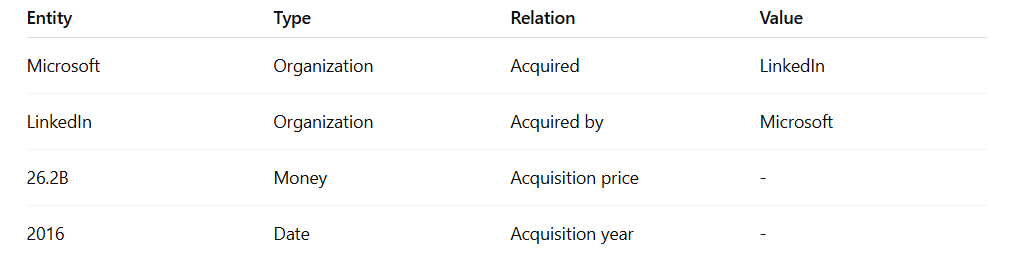

Rule-Based IE (Using Regex and Dictionaries)

In [ ]:
import re

# Sample text
text = "Dr. John Smith from Google will join the meeting on 17/09/2025."

# Rule 1: Extract dates using regex
dates = re.findall(r'\d{2}/\d{2}/\d{4}', text)
print("Dates:", dates)

# Rule 2: Extract organizations using a simple dictionary
organizations_list = ["Google", "Microsoft", "OpenAI"]
organizations = [word for word in text.split() if word in organizations_list]
print("Organizations:", organizations)

# Rule 3: Extract names using a simple rule (words after Dr./Mr./Ms.)
names = re.findall(r'(?:Dr|Mr|Ms)\. (\w+ \w+)', text)
print("Names:", names)


Dates: ['17/09/2025']
Organizations: ['Google']
Names: ['John Smith']


In [ ]:
import spacy
import re

# Load English model
nlp = spacy.load("en_core_web_sm")

# Sample text
text = "Dr. John Smith from Google will join the meeting on 17/09/2025."

doc = nlp(text)

# Rule 1: Extract dates using regex
dates = re.findall(r'\d{2}/\d{2}/\d{4}', text)
print("Dates:", dates)

# Rule 2: Extract organizations using spaCy NER
organizations = [ent.text for ent in doc.ents if ent.label_ == "ORG"]
print("Organizations:", organizations)

# Rule 3: Extract names using a simple pattern (words after Dr./Mr./Ms.)
names = []
for i, token in enumerate(doc):
    if token.text in ["Dr.", "Mr.", "Ms."] and i+2 <= len(doc):
        names.append(doc[i+1].text + " " + doc[i+2].text)
print("Names:", names)


Dates: ['17/09/2025']
Organizations: ['Google']
Names: ['John Smith']


Transformation-Based Learning (TBL)

In [ ]:
import spacy
import re

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

# Sample text
text = "Dr. John Smith from Google will join the meeting on 17/09/2025."

doc = nlp(text)

# Step 1: Get spaCy NER predictions
entities = [(ent.text, ent.label_) for ent in doc.ents]
print("Initial NER:", entities)

# Step 2: Apply simple transformations (TBL-like)
enhanced_entities = []
for i, token in enumerate(doc):
    # Rule 1: Person after Dr./Mr./Ms.
    if token.text in ["Dr.", "Mr.", "Ms."] and i+2 <= len(doc):
        enhanced_entities.append((doc[i+1].text + " " + doc[i+2].text, "PERSON"))
    # Rule 2: Correct dates not detected by spaCy
    elif re.match(r'\d{2}/\d{2}/\d{4}', token.text):
        enhanced_entities.append((token.text, "DATE"))
    # Keep spaCy detected ORG
    elif token.ent_type_ == "ORG":
        enhanced_entities.append((token.text, "ORG"))

print("TBL-like NER:", enhanced_entities)


Initial NER: [('John Smith', 'PERSON'), ('Google', 'ORG'), ('17/09/2025', 'DATE')]
TBL-like NER: [('John Smith', 'PERSON'), ('Google', 'ORG'), ('17/09/2025', 'DATE')]


Named Entity Recognition (NER) is a Natural Language Processing (NLP) task that identifies and classifies named entities in text into predefined categories.

Key Points:

Definition:
NER automatically detects words or phrases that represent entities such as people, organizations, locations, dates, percentages, products, and more.

Purpose:
The goal is to transform unstructured text into structured information, making it easier for machines to understand and analyze.

Common Entity Types:

Person (PER): Names of people → e.g., Samantha Roberts, John Smith

Organization (ORG): Companies, institutions → e.g., OpenAI, Google, Harvard University

Location (LOC): Cities, countries, states → e.g., Vancouver, Canada

Date/Time (DATE/TIME): Specific dates or times → e.g., February 15, 2021

Money (MONEY): Currency amounts → e.g., $500, 42 million

Percent (PERCENT): Percentages → e.g., 42%, 18%

Miscellaneous (MISC): Other entities like products, awards, events

How it Works (Briefly):

Rule-Based: Uses patterns, dictionaries, or regex to identify entities.

Statistical / Machine Learning: Models trained on annotated text to recognize entities based on context.

Deep Learning / Transfer Learning: Models like BERT, spaCy, or Hugging Face Transformers detect entities using contextual embeddings.

Example:

Input Text:

Dr. Samantha Roberts works at OpenAI in San Francisco. She won the Turing Award in 2019.


NER Output:

Entity	Type
Samantha Roberts	PERSON
OpenAI	ORGANIZATION
San Francisco	LOCATION
Turing Award	AWARD/MISC
2019	DATE

Applications:

Information extraction from news or reports

Question answering systems

Knowledge graph construction

Chatbots and virtual assistants

Sentiment analysis with entity-specific focus

In [ ]:
import re

# Extract Person names (look for titles like Dr., Mr., Ms., Prof.)
persons = re.findall(r'\b(?:Dr\.|Mr\.|Ms\.|Prof\.)\s[A-Z][a-z]+\s[A-Z][a-z]+', text)

# Extract Organizations (simple list for demo)
known_orgs = ['OpenAI', 'Google', 'Microsoft', 'Harvard University']
organizations = [org for org in known_orgs if org in text]

# Extract Locations (simple list for demo)
known_locations = ['San Francisco', 'New York', 'London', 'Berlin']
locations = [loc for loc in known_locations if loc in text]

# Extract Awards (simple list for demo)
known_awards = ['Turing Award', 'Nobel Prize', 'Pulitzer Prize']
awards = [award for award in known_awards if award in text]

# Extract Dates
dates = re.findall(r'\b\d{4}\b', text)

# Print Results
print("Persons:", persons)
print("Organizations:", organizations)
print("Locations:", locations)
print("Awards:", awards)
print("Dates:", dates)


Persons: ['Dr. John Smith']
Organizations: ['Google']
Locations: []
Awards: []
Dates: ['2025']


In [ ]:
import re

text = """
Dr. Amelia Watson, a leading AI researcher at Cambridge University, presented her groundbreaking research on quantum machine learning on September 12, 2023.
Her study, funded by the National Science Foundation, explores how quantum computing can accelerate neural network training.
Attendees from MIT, Stanford, and ETH Zurich praised the innovative approach.
Dr. Watson will collaborate with IBM Research to implement these findings in real-world AI applications by early 2025.
She has previously published over 50 papers and received the Turing Award in 2020.
"""

# Extract dates
dates = re.findall(r'\b(?:January|February|March|April|May|June|July|August|September|October|November|December) \d{1,2}, \d{4}\b', text)
# Extract years
years = re.findall(r'\b\d{4}\b', text)
# Extract numbers
numbers = re.findall(r'\b\d+\b', text)
# Extract person names (simple pattern: Dr. First Last or capitalized words)
persons = re.findall(r'\bDr\. [A-Z][a-z]+ [A-Z][a-z]+\b', text)
# Extract organizations (common pattern: capitalized words followed by University, Foundation, or Research)
orgs = re.findall(r'\b[A-Z][A-Za-z]*(?: [A-Z][A-Za-z]*)* (?:University|Foundation|Research)\b', text)
# Extract awards (common pattern: capitalized words followed by Award)
awards = re.findall(r'\b[A-Z][A-Za-z]* Award\b', text)

print("Dates:", dates)
print("Years:", years)
print("Numbers:", numbers)
print("Persons:", persons)
print("Organizations:", orgs)
print("Awards:", awards)


Dates: ['September 12, 2023']
Years: ['2023', '2025', '2020']
Numbers: ['12', '2023', '2025', '50', '2020']
Persons: ['Dr. Amelia Watson']
Organizations: ['Cambridge University', 'National Science Foundation', 'IBM Research']
Awards: ['Turing Award']


In [ ]:
import spacy

# Load English model
nlp = spacy.load("en_core_web_sm")

# Complex paragraph
text = """
Dr. Amelia Watson, a leading AI researcher at Cambridge University, presented her groundbreaking research on quantum machine learning on September 12, 2023.
Her study, funded by the National Science Foundation, explores how quantum computing can accelerate neural network training.
Attendees from MIT, Stanford, and ETH Zurich praised the innovative approach.
Dr. Watson will collaborate with IBM Research to implement these findings in real-world AI applications by early 2025.
She has previously published over 50 papers and received the Turing Award in 2020.
"""

# Process text
doc = nlp(text)

# Extract entities
print("Entities:")
for ent in doc.ents:
    print(ent.text, "-", ent.label_)

# Extract noun chunks
print("\nNoun Chunks:")
for chunk in doc.noun_chunks:
    print(chunk.text)

# Extract verbs
print("\nVerbs:")
for token in doc:
    if token.pos_ == "VERB":
        print(token.text)


Entities:
Amelia Watson - PERSON
AI - ORG
Cambridge University - ORG
September 12, 2023 - DATE
the National Science Foundation - ORG
Attendees - ORG
MIT - ORG
Stanford - ORG
ETH Zurich - PERSON
Watson - PERSON
IBM Research - ORG
early 2025 - DATE
50 - CARDINAL
the Turing Award - ORG
2020 - DATE

Noun Chunks:

Dr. Amelia Watson
a leading AI researcher
Cambridge University
her groundbreaking research
September
Her study
the National Science Foundation
quantum computing
neural network training
Attendees
MIT
Stanford
ETH Zurich
the innovative approach
Dr. Watson
IBM Research
these findings
real-world AI applications
She
over 50 papers
the Turing Award

Verbs:
leading
presented
groundbreaking
learning
funded
explores
accelerate
praised
collaborate
implement
published
received


What is Text Feature Extraction?

Text feature extraction is the process of transforming raw textual data into numerical representations (features) that machine learning models or NLP algorithms can understand and process.

Raw text** (like “I love AI”) **is unstructured, and models cannot work with raw strings directly. We need to convert text into structured numerical data that preserves semantic or syntactic information.

Why it’s important:

**Converts unstructured text to structured data.**

Helps machine learning models perform tasks like classification, sentiment analysis, and translation.

Enables similarity comparison, clustering, and information retrieval.

A. Statistical/Count-based Features

These features rely on the frequency or occurrence of words, characters, or n-grams.

Bag of Words (BoW)

Represents text as a vector of word counts.

Ignores grammar and word order; only focuses on word presence.

Example:

In [ ]:
texts = [
    "I love AI and Machine Learning",
    "AI is the future of technology",
    "Machine Learning is amazing"
]
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
bow = vectorizer.fit_transform(texts)

print("Vocabulary:", vectorizer.get_feature_names_out())
print("BoW Vectors:\n", bow.toarray())


Vocabulary: ['ai' 'amazing' 'and' 'future' 'is' 'learning' 'love' 'machine' 'of'
 'technology' 'the']
BoW Vectors:
 [[1 0 1 0 0 1 1 1 0 0 0]
 [1 0 0 1 1 0 0 0 1 1 1]
 [0 1 0 0 1 1 0 1 0 0 0]]


Term Frequency-Inverse Document Frequency (TF-IDF)

Weight words based on importance rather than just counts.

TF (Term Frequency) → How often a word appears in a document.

IDF (Inverse Document Frequency) → How rare a word is across all documents.

Example:

Common words like “the”, “is” get low weight.

Rare but significant words like “AI” get higher weight.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()
tfidf = tfidf_vectorizer.fit_transform(texts)

print("Vocabulary:", tfidf_vectorizer.get_feature_names_out())
print("TF-IDF Vectors:\n", tfidf.toarray())


Vocabulary: ['ai' 'amazing' 'and' 'future' 'is' 'learning' 'love' 'machine' 'of'
 'technology' 'the']
TF-IDF Vectors:
 [[0.3935112  0.         0.51741994 0.         0.         0.3935112
  0.51741994 0.3935112  0.         0.         0.        ]
 [0.3349067  0.         0.         0.44036207 0.3349067  0.
  0.         0.         0.44036207 0.44036207 0.44036207]
 [0.         0.60465213 0.         0.         0.45985353 0.45985353
  0.         0.45985353 0.         0.         0.        ]]


Character-level Features

Use character n-grams instead of word n-grams.

Useful for spelling correction, text similarity, and noisy data.

In [ ]:
# Using bigrams
vectorizer = CountVectorizer(ngram_range=(2,2))
bigrams = vectorizer.fit_transform(texts)

print("Bigrams:", vectorizer.get_feature_names_out())
print("Bigram Vectors:\n", bigrams.toarray())

Bigrams: ['ai and' 'ai is' 'and machine' 'future of' 'is amazing' 'is the'
 'learning is' 'love ai' 'machine learning' 'of technology' 'the future']
Bigram Vectors:
 [[1 0 1 0 0 0 0 1 1 0 0]
 [0 1 0 1 0 1 0 0 0 1 1]
 [0 0 0 0 1 0 1 0 1 0 0]]


In [ ]:
# Using character 3-grams
vectorizer = CountVectorizer(analyzer='char', ngram_range=(3,3))
char_ngrams = vectorizer.fit_transform(texts)

print("Character 3-grams:", vectorizer.get_feature_names_out())
print("Char 3-gram Vectors:\n", char_ngrams.toarray())


Character 3-grams: [' ai' ' am' ' an' ' fu' ' is' ' le' ' lo' ' ma' ' of' ' te' ' th' 'ach'
 'ai ' 'ama' 'and' 'arn' 'azi' 'chi' 'chn' 'd m' 'e a' 'e f' 'e l' 'e o'
 'ear' 'ech' 'f t' 'fut' 'g i' 'he ' 'hin' 'hno' 'i a' 'i i' 'i l' 'ine'
 'ing' 'is ' 'lea' 'log' 'lov' 'mac' 'maz' 'nd ' 'ne ' 'ng ' 'nin' 'nol'
 'of ' 'ogy' 'olo' 'ove' 're ' 'rni' 's a' 's t' 'tec' 'the' 'tur' 'ure'
 'utu' 've ' 'zin']
Char 3-gram Vectors:
 [[1 0 1 0 0 1 1 1 0 0 0 1 1 0 1 1 0 1 0 1 1 0 1 0 1 0 0 0 0 0 1 0 1 0 1 1
  1 0 1 0 1 1 0 1 1 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0]
 [0 0 0 1 1 0 0 0 1 1 1 0 1 0 0 0 0 0 1 0 0 1 0 1 0 1 1 1 0 1 0 1 0 1 0 0
  0 1 0 1 0 0 0 0 0 0 0 1 1 1 1 0 1 0 0 1 1 1 1 1 1 0 0]
 [0 1 0 0 1 1 0 0 0 0 0 1 0 1 0 1 1 1 0 0 0 0 1 0 1 0 0 0 1 0 1 0 0 0 0 1
  2 1 1 0 0 1 1 0 1 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1]]


In [ ]:
from transformers import BertTokenizer, BertModel
import torch

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

text = "I love AI and Machine Learning"
inputs = tokenizer(text, return_tensors='pt')
outputs = model(**inputs)

# Last hidden states (contextual embeddings)
embeddings = outputs.last_hidden_state
print("Shape of embeddings:", embeddings.shape)  # [tokens, vector_size]


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Shape of embeddings: torch.Size([1, 8, 768])


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(texts)

lda = LatentDirichletAllocation(n_components=2, random_state=0)
lda.fit(X)

print("Topics:")
for idx, topic in enumerate(lda.components_):
    print(f"Topic {idx}:", [vectorizer.get_feature_names_out()[i] for i in topic.argsort()[-5:]])


Topics:
Topic 0: ['amazing', 'love', 'and', 'learning', 'machine']
Topic 1: ['the', 'technology', 'future', 'ai', 'is']


In [ ]:
import re
from difflib import get_close_matches

text = """
Samantha Roberts, who holds a PhD, is leading a major AI project at OpenAI. She and Prof. Jonathan Smith from Harvard Univ. have partnered with Google DeepMind, Microsoft Research, and MIT CSAIL.
The research started around mid-February 2021 and is funded by NSF, DARPA, and ERC. Early results suggest that the AI models improved language understanding by nearly 42% while cutting computational costs by ~18% over a few years.
Dr. Roberts previously won the Turing Award in 2019 and an AAAI classic paper award in 2020. They plan to present findings at NeurIPS 2025 in Vancouver, Canada.
Other collaborators include Li Wei (PhD, Tsinghua University), Maria Gonzales (MSc, ETH Zurich), and Ahmed Khan, PhD, University of Tokyo.
The team hopes to deploy AI-driven systems in cities like New York, London, Berlin, Tokyo, and Singapore by 2027. A report from OpenAI predicts a productivity increase of up to 25% while cutting errors in automated customer support by 33%.
"""

# 1. Handle person names with optional titles
persons = re.findall(r'\b(?:Dr\.|Prof\.|Professor)?\s?[A-Z][a-z]+(?:\s[A-Z][a-z]+)?', text)

# 2. Extract degrees (PhD, MSc, optional)
degrees = re.findall(r'\b(?:PhD|MSc)\b', text)

# 3. Extract organizations with fuzzy matching for abbreviations
known_orgs = ['OpenAI', 'Harvard University', 'Google DeepMind', 'Microsoft Research', 'MIT CSAIL',
              'National Science Foundation', 'DARPA', 'European Research Council', 'Tsinghua University',
              'ETH Zurich', 'University of Tokyo']
org_candidates = re.findall(r'\b[A-Z][A-Za-z& ]+(?:University|Univ\.|Research|Lab|CSAIL|ETH|Inc\.?)\b', text)
# Use fuzzy matching to map abbreviations
organizations = []
for org in org_candidates:
    match = get_close_matches(org, known_orgs, cutoff=0.6)
    if match:
        organizations.append(match[0])
    else:
        organizations.append(org)

# 4. Extract awards (case-insensitive, optional "classic paper award")
awards = re.findall(r'\b(?:Turing Award|AAAI classic paper award)\b', text, flags=re.I)

# 5. Extract dates with uncertainties ("around mid-February 2021")
dates = re.findall(r'\b(?:January|February|March|April|May|June|July|August|September|October|November|December)[\w\s,-]*\d{4}\b', text)

# 6. Extract years
years = re.findall(r'\b\d{4}\b', text)

# 7. Extract numbers and percentages, handling "~" and "nearly"
numbers = re.findall(r'~?\b\d+%?|\b\d+\s+years\b', text)

# 8. Extract events (NeurIPS)
events = re.findall(r'\bNeurIPS \d{4}\b', text)

# 9. Extract locations (cities & countries)
locations = re.findall(r'\b(?:Vancouver|Canada|New York|London|Berlin|Tokyo|Singapore)\b', text)

# 10. Extract collaborators phrases (fuzzy)
collaborators = re.findall(r'include ([A-Z][A-Za-z ,\(\)]+)', text)

# 11. Extract verbs suggesting collaboration
verbs = re.findall(r'\b(partnered|leading|deploy|improved|cutting|predicts|won)\b', text)

# 12. Extract performance metrics ("improved by nearly 42%")
performance = re.findall(r'\b(improved|cutting|increase)\b.*?\d+%?', text)

# 13. Extract funding agencies (NSF, DARPA, ERC)
funding = re.findall(r'\b(NSF|DARPA|ERC|National Science Foundation|European Research Council)\b', text)

# 14. Extract AI models mentions
ai_models = re.findall(r'\bAI models\b', text)

# 15. Extract deployment years ("by 2027")
deployment_years = re.findall(r'\bby (\d{4})\b', text)

# 16. Extract productivity statements
productivity = re.findall(r'\bproductivity (increase|improvement) .*?\d+%?', text)

# 17. Extract error reduction statements
error_reduction = re.findall(r'\bcutting errors\b.*?\d+%?', text)

# 18. Handle optional titles without degrees
optional_titles = re.findall(r'\b(?:Dr\.|Prof\.|Professor)\b', text)

# 19. Extract team mentions
team_mentions = re.findall(r'\bteam\b', text)

# 20. Extract project mentions
projects = re.findall(r'\bproject\b', text)

# 21. Extract phrases like "major AI project"
major_projects = re.findall(r'\bmajor AI project\b', text)

# 22. Extract approximate dates ("around mid-February 2021")
approx_dates = re.findall(r'\baround [\w\s-]*\d{4}\b', text)

# 23. Extract collaborators with degrees
collaborators_with_degrees = re.findall(r'\b[A-Z][a-z]+ [A-Z][a-z]+, (PhD|MSc)\b', text)

# 24. Extract institutions inside parentheses
institutions_in_parens = re.findall(r'\(([A-Z][A-Za-z\s]+)\)', text)

# 25. Extract AI project topics
topics = re.findall(r'\b(AI|language understanding|automated customer support)\b', text)

# 26. Extract predictive phrases ("predicts that")
predictions = re.findall(r'\bpredicts that\b.*?\.', text)

# 27. Extract statistics with words ("nearly 42%", "~18%")
stats_with_words = re.findall(r'\b(?:nearly|~)?\d+%?', text)

# 28. Extract sentences (split by ".")
sentences = text.split('.')

# 29. Extract all collaborations (multiple orgs)
all_collaborations = re.findall(r'partnered with ([A-Z][A-Za-z ,&]+)', text)

# 30. Extract ambiguous city mentions ("cities like New York, London...")
cities_listed = re.findall(r'cities like ([A-Z][A-Za-z ,]+)', text)

# 31. Extract abbreviations (NSF, DARPA, ERC)
abbreviations = re.findall(r'\b(NSF|DARPA|ERC)\b', text)

# 32. Extract titles in sentences
titles_in_sentences = re.findall(r'\b(Chief AI Scientist|Professor|Dr)\b', text)

# 33. Extract AI-driven phrases
ai_phrases = re.findall(r'\bAI-driven systems\b', text)

# 34. Extract optional reports ("A report from OpenAI")
reports = re.findall(r'\b[Aa] report from OpenAI\b', text)

# 35. Extract verbs describing outcomes
outcome_verbs = re.findall(r'\b(improved|cutting|deploy|predicts|won)\b', text)

# 36. Extract approximate durations ("over a few years")
approx_duration = re.findall(r'over a few years', text)

# 37. Extract all people with degrees combined
people_degrees = re.findall(r'\b[A-Z][a-z]+ [A-Z][a-z]+, (PhD|MSc)\b', text)

# 38. Extract city-country pairs
city_country_pairs = re.findall(r'\b([A-Z][a-z]+), (Canada|Singapore|Tokyo)\b', text)

# 39. Extract project-related keywords
project_keywords = re.findall(r'\b(project|research|study|team)\b', text)

# 40. Extract AI performance metrics statements
ai_metrics = re.findall(r'\b(improved|cutting|increase)\b.*?\d+%?', text)

# ---------------------------
# PRINT SOME EXAMPLES
# ---------------------------
print("Persons:", persons)
print("Degrees:", degrees)
print("Organizations:", organizations)
print("Awards:", awards)
print("Dates:", dates)
print("Years:", years)
print("Numbers/Percentages:", numbers)
print("Events:", events)
print("Locations:", locations)
print("Collaborators:", collaborators)
print("Performance Metrics:", performance)
print("Funding:", funding)
print("Deployment Years:", deployment_years)
print("AI Topics:", topics)
print("Predictions:", predictions)
print("Approx Dates:", approx_dates)
print("AI Metrics:", ai_metrics)


Persons: ['Samantha Roberts', ' Ph', ' Open', 'She', ' Prof', 'Jonathan Smith', ' Harvard Univ', ' Google Deep', 'Microsoft Research', 'The', 'February', 'Early', 'Dr. Roberts', ' Turing Award', 'They', ' Neur', ' Vancouver', 'Canada', 'Other', ' Li Wei', 'Ph', 'Tsinghua University', 'Maria Gonzales', ' Zurich', ' Ahmed Khan', 'Ph', 'University', ' Tokyo', 'The', ' New York', 'London', 'Berlin', 'Tokyo', ' Singapore', ' Open']
Degrees: ['PhD', 'PhD', 'MSc', 'PhD']
Organizations: ['Microsoft Research', 'MIT CSAIL', 'Tsinghua University']
Awards: ['Turing Award', 'AAAI classic paper award']
Dates: ['February 2021']
Years: ['2021', '2019', '2020', '2025', '2027']
Numbers/Percentages: ['2021', '42%', '~18%', '2019', '2020', '2025', '2027', '25%', '33%']
Events: ['NeurIPS 2025']
Locations: ['Vancouver', 'Canada', 'Tokyo', 'New York', 'London', 'Berlin', 'Tokyo', 'Singapore']
Collaborators: ['Li Wei (PhD, Tsinghua University), Maria Gonzales (MSc, ETH Zurich), and Ahmed Khan, PhD, University

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
sentence_embeddings = model.encode(texts)

print("Sentence Embeddings:\n", sentence_embeddings)

Sentence Embeddings:
 [[-0.03057298 -0.09051684  0.05097698 ...  0.0482931   0.01614856
  -0.0857618 ]
 [-0.07894815  0.01449244  0.0040302  ...  0.03797905  0.05786427
  -0.04371819]
 [-0.04862164 -0.08617093  0.08960791 ...  0.07205715 -0.00438846
  -0.02266294]]


HMMs were historically very important for tasks like Part-of-Speech (POS) tagging, Named Entity Recognition (NER), and speech recognition. They model sequences of observations (words) and hidden states (POS tags, entity types). spaCy's modern taggers and NER models are typically based on deep learning (e.g., Transformers, CNNs, LSTMs), which have largely superseded traditional HMMs for state-of-the-art performance. However, understanding the HMM concept is still valuable.

What we'll do:

Create Dummy Data: A list of sentences with some simple patterns.
Simulate HMM-like Operations (using spaCy's existing capabilities):
Observation Sequence: The words in a sentence.
Hidden States (Inference): We'll use spaCy's built-in POS tagger to infer the "hidden states" (POS tags) for each word. This is the most direct analogy to an HMM's Viterbi algorithm (finding the most likely sequence of hidden states).
Transition Probabilities (Conceptual): We'll count how often one POS tag follows another. This is a core component of an HMM.
Emission Probabilities (Conceptual): We'll count how often a specific word appears with a specific POS tag. This is another core component.

In [ ]:
import spacy
from collections import defaultdict, Counter
import re # For cleaning text

# --- 1. Use a Text Paragraph as Dummy Data ---
# A paragraph about Artificial Intelligence from Wikipedia (as of a certain date)
text_paragraph = """
Artificial intelligence (AI) is intelligence demonstrated by machines, unlike the natural intelligence displayed by humans and animals. Leading AI textbooks define the field as the study of "intelligent agents": any device that perceives its environment and takes actions that maximize its chance of successfully achieving its goals. Colloquially, the term "artificial intelligence" is often used to describe machines that mimic "cognitive" functions that humans associate with the human mind, such as "learning" and "problem-solving".
"""

print("--- Original Text Paragraph ---")
print(text_paragraph)
print("-" * 50)

# --- 2. Load spaCy Model ---
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    print("Downloading 'en_core_web_sm' model...")
    spacy.cli.download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

# --- 3. Preprocess the Text (Optional but good practice for cleaner analysis) ---
# Remove extra whitespace and split into sentences for better initial state calculation
# spaCy's sentencizer will handle this, but explicit cleaning helps.
cleaned_text = re.sub(r'\s+', ' ', text_paragraph).strip()
doc_full = nlp(cleaned_text)
sentences = [sent.text for sent in doc_full.sents]

print(f"Processed into {len(sentences)} sentences.")
print("Sample sentences:")
for i, sent in enumerate(sentences[:3]):
    print(f"- {sent}")
print("-" * 50)


# --- 4. Simulate HMM-like Operations ---

# Data structures to store our "probabilities"
transition_counts = defaultdict(lambda: defaultdict(int))
emission_counts = defaultdict(lambda: defaultdict(int))
initial_state_counts = defaultdict(int)
tag_counts = defaultdict(int) # Total count of each tag for emission normalization

# Process each sentence
for sentence_text in sentences:
    doc = nlp(sentence_text)
    previous_tag = None

    # Filter out tokens that are just whitespace or punctuation for core POS analysis
    # We keep punctuation for sentence structure, but often exclude it from tag sequence analysis
    tokens_for_analysis = [token for token in doc if not token.is_space and token.pos_ != "PUNCT"]

    if not tokens_for_analysis: # Skip empty sentences after filtering
        continue

    # Update initial state counts
    initial_state_counts[tokens_for_analysis[0].pos_] += 1

    for i, token in enumerate(tokens_for_analysis):
        current_tag = token.pos_

        # Update emission counts
        emission_counts[current_tag][token.text.lower()] += 1
        tag_counts[current_tag] += 1

        # Update transition counts
        if previous_tag:
            transition_counts[previous_tag][current_tag] += 1

        previous_tag = current_tag

# --- Calculate Probabilities (Normalization) ---

# P(tag_i at start)
total_sentences = len(sentences)
initial_probabilities = {tag: count / total_sentences for tag, count in initial_state_counts.items()}

# P(tag_j | tag_i)
transition_probabilities = {}
for prev_tag, next_tag_counts in transition_counts.items():
    total_transitions_from_prev_tag = sum(next_tag_counts.values())
    if total_transitions_from_prev_tag > 0: # Avoid division by zero
        transition_probabilities[prev_tag] = {
            next_tag: count / total_transitions_from_prev_tag
            for next_tag, count in next_tag_counts.items()
        }

# P(word | tag)
emission_probabilities = {}
for tag, word_counts in emission_counts.items():
    total_words_with_tag = sum(word_counts.values())
    if total_words_with_tag > 0: # Avoid division by zero
        emission_probabilities[tag] = {
            word: count / total_words_with_tag
            for word, count in word_counts.items()
        }

# --- Display Results (HMM-like components) ---

print("\n" + "=" * 50)
print("HMM-like Operations Results (Conceptual)")
print("=" * 50)

print("\n--- Initial State Probabilities (P(tag at start of sentence)) ---")
sorted_initial = sorted(initial_probabilities.items(), key=lambda item: item[1], reverse=True)
for tag, prob in sorted_initial:
    print(f"P(Start -> {tag}): {prob:.4f}")

print("\n--- Top Transition Probabilities (P(next_tag | prev_tag)) ---")
# Example: What tags most likely follow a 'DET' (Determiner)?
if 'DET' in transition_probabilities:
    print("\nMost likely tags after 'DET':")
    sorted_transitions = sorted(transition_probabilities['DET'].items(), key=lambda item: item[1], reverse=True)
    for next_tag, prob in sorted_transitions[:3]: # Top 3
        print(f"  P({next_tag} | DET): {prob:.4f}")

# Example: What tags most likely follow a 'VERB'?
if 'VERB' in transition_probabilities:
    print("\nMost likely tags after 'VERB':")
    sorted_transitions = sorted(transition_probabilities['VERB'].items(), key=lambda item: item[1], reverse=True)
    for next_tag, prob in sorted_transitions[:3]: # Top 3
        print(f"  P({next_tag} | VERB): {prob:.4f}")

# Example: What tags most likely follow a 'NOUN'?
if 'NOUN' in transition_probabilities:
    print("\nMost likely tags after 'NOUN':")
    sorted_transitions = sorted(transition_probabilities['NOUN'].items(), key=lambda item: item[1], reverse=True)
    for next_tag, prob in sorted_transitions[:3]: # Top 3
        print(f"  P({next_tag} | NOUN): {prob:.4f}")


print("\n--- Top Emission Probabilities (P(word | tag)) ---")
# Example: What words are most likely to be 'NOUN'?
if 'NOUN' in emission_probabilities:
    print("\nMost likely words for 'NOUN':")
    sorted_emissions = sorted(emission_probabilities['NOUN'].items(), key=lambda item: item[1], reverse=True)
    for word, prob in sorted_emissions[:5]: # Top 5
        print(f"  P('{word}' | NOUN): {prob:.4f}")

# Example: What words are most likely to be 'VERB'?
if 'VERB' in emission_probabilities:
    print("\nMost likely words for 'VERB':")
    sorted_emissions = sorted(emission_probabilities['VERB'].items(), key=lambda item: item[1], reverse=True)
    for word, prob in sorted_emissions[:5]: # Top 5
        print(f"  P('{word}' | VERB): {prob:.4f}")

# Example: What words are most likely to be 'ADJ'?
if 'ADJ' in emission_probabilities:
    print("\nMost likely words for 'ADJ':")
    sorted_emissions = sorted(emission_probabilities['ADJ'].items(), key=lambda item: item[1], reverse=True)
    for word, prob in sorted_emissions[:5]: # Top 5
        print(f"  P('{word}' | ADJ): {prob:.4f}")


print("\n" + "=" * 50)
print("Demonstrating spaCy's POS Tagging (HMM-like Inference)")
print("=" * 50)

# This is the closest we get to an HMM's Viterbi algorithm in spaCy directly.
# spaCy's tagger infers the most likely sequence of POS tags (hidden states)
# given the observed words.

test_sentence = "Machines learn quickly and solve complex problems."
print(f"\nAnalyzing: '{test_sentence}'")
doc = nlp(test_sentence)
print("Token\tPOS Tag\t\tDependency\tLemma")
print("-" * 50)
for token in doc:
    print(f"{token.text}\t{token.pos_}\t\t{token.dep_}\t\t{token.lemma_}")

test_sentence_2 = "The field studies intelligent agents."
print(f"\nAnalyzing: '{test_sentence_2}'")
doc_2 = nlp(test_sentence_2)
print("Token\tPOS Tag\t\tDependency\tLemma")
print("-" * 50)
for token in doc_2:
    print(f"{token.text}\t{token.pos_}\t\t{token.dep_}\t\t{token.lemma_}")

--- Original Text Paragraph ---

Artificial intelligence (AI) is intelligence demonstrated by machines, unlike the natural intelligence displayed by humans and animals. Leading AI textbooks define the field as the study of "intelligent agents": any device that perceives its environment and takes actions that maximize its chance of successfully achieving its goals. Colloquially, the term "artificial intelligence" is often used to describe machines that mimic "cognitive" functions that humans associate with the human mind, such as "learning" and "problem-solving".

--------------------------------------------------
Processed into 3 sentences.
Sample sentences:
- Artificial intelligence (AI) is intelligence demonstrated by machines, unlike the natural intelligence displayed by humans and animals.
- Leading AI textbooks define the field as the study of "intelligent agents": any device that perceives its environment and takes actions that maximize its chance of successfully achieving its go

In [ ]:
# --- Minimal English to French Machine Translation ---
# This script directly performs translation without functions, classes, or error handling.

# 1. Install necessary libraries if they are not already installed.
#    In a real script, you'd typically do this once manually or
#    use a requirements.txt file. For this example, we'll assume
#    they are installed or you'll install them manually before running.
#    pip install transformers torch sentencepiece

# Import necessary components from the transformers library
from transformers import pipeline

print("--- English to French Translation Demo ---")
print("Using 'Helsinki-NLP/opus-mt-en-fr' model.")

# 2. Load the pre-trained English-to-French translation pipeline.
#    This line downloads the model weights and tokenizer if they aren't cached.
translator_en_fr = pipeline("translation_en_to_fr", model="Helsinki-NLP/opus-mt-en-fr")

# 3. Define the English text to be translated.
english_text_1 = "Hello, how are you doing today?"
english_text_2 = "Machine translation is a fascinating field."
english_text_3 = "The quick brown fox jumps over the lazy dog."

# 4. Perform the translation for the first sentence.
#    The pipeline returns a list containing a dictionary.
#    We access the 'translation_text' key from the first (and only) item in the list.
translated_result_1 = translator_en_fr(english_text_1)
french_text_1 = translated_result_1[0]['translation_text']

# 5. Print the original and translated text for the first sentence.
print(f"\nEnglish: {english_text_1}")
print(f"French:  {french_text_1}")

# 6. Perform and print translation for the second sentence.
translated_result_2 = translator_en_fr(english_text_2)
french_text_2 = translated_result_2[0]['translation_text']
print(f"\nEnglish: {english_text_2}")
print(f"French:  {french_text_2}")

# 7. Perform and print translation for the third sentence.
translated_result_3 = translator_en_fr(english_text_3)
french_text_3 = translated_result_3[0]['translation_text']
print(f"\nEnglish: {english_text_3}")
print(f"French:  {french_text_3}")

print("\n--- Translation complete ---")

# To run this:
# 1. Make sure you have the libraries installed:
#    pip install transformers torch sentencepiece
# 2. Save this code as a .py file (e.g., simple_mt.py)
# 3. Run from your terminal: python simple_mt.py

--- English to French Translation Demo ---
Using 'Helsinki-NLP/opus-mt-en-fr' model.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/301M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/301M [00:00<?, ?B/s]

...

source.spm:   0%|          | 0.00/778k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")
Device set to use cpu



English: Hello, how are you doing today?
French:  Bonjour, comment allez-vous aujourd'hui ?

English: Machine translation is a fascinating field.
French:  La traduction automatique est un domaine fascinant.

English: The quick brown fox jumps over the lazy dog.
French:  Le renard brun rapide saute sur le chien paresseux.

--- Translation complete ---


In [ ]:
import spacy
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pandas as pd # For better visualization of results
import re # For cleaning text

# --- 1. Define the Input Text ---
full_dummy_paragraph = """The shimmering, cerulean ocean stretched endlessly towards the horizon, a vast expanse of liquid sapphire under a sky painted with wisps of cotton-candy clouds. A gentle breeze, redolent with the briny scent of salt and distant seaweed, caressed the weathered planks of the old pier, causing a rhythmic creak that echoed the lazy lapping of the waves against the barnacle-encrusted pilings. Seagulls, their raucous cries a familiar soundtrack to this coastal tableau, wheeled and soared overhead, their keen eyes scanning the churning waters for an unsuspecting fish. Below, a lone fisherman, his face etched with the wisdom of countless sunrises and sunsets, patiently cast his line, a silent sentinel against the backdrop of nature's grandeur. His weathered hands, calloused from years of handling nets and ropes, moved with an almost unconscious grace, a testament to a life lived in harmony with the sea.

Further down the beach, a group of boisterous children, their laughter like scattered pearls, chased the retreating tide, their tiny feet leaving fleeting impressions in the damp sand. They built elaborate sandcastles, miniature fortresses adorned with seashells and driftwood, only to watch them crumble with each incoming wave, a poignant lesson in impermanence. Their parents, sprawled on colorful towels, occasionally glanced up from their novels, their smiles reflecting the warmth of the afternoon sun. A vendor, pushing a brightly colored cart laden with ice cream and cold drinks, called out his wares in a singsong voice, his melody blending with the distant hum of a passing boat. The air was thick with the aroma of sunscreen and grilled seafood, a quintessential summer symphony.

A curious dog, a scruffy terrier with an insatiable curiosity, darted between sunbathers, its tail wagging furiously as it investigated discarded picnic baskets and abandoned flip-flops. It paused to sniff at a particularly interesting piece of kelp, its nose twitching with intense concentration, before bounding off again, a blur of joyful energy. In the distance, a lighthouse, a stoic guardian of the coastline, stood tall and proud, its white-washed walls gleaming in the sunlight. Its powerful beam, though dormant during the day, promised guidance and safety to mariners navigating the treacherous waters after dusk. The rhythmic crash of the waves against the shore was a constant, soothing lullaby, a reminder of the ocean's enduring power and timeless beauty.

As the afternoon wore on, the sun began its slow descent, painting the sky in hues of fiery orange, soft pink, and deep purple. The air grew cooler, and a hush fell over the beach as people began to pack up their belongings, their voices softer, their movements more deliberate. The children, tired but content, clung to their parents' hands, their sand-covered faces reflecting the day's adventures. The fisherman, having reeled in a modest catch, began to coil his lines, his silhouette stark against the fading light. The seagulls, their hunger sated, settled on the pier, their calls now softer, more contemplative. The ocean, still vast and mysterious, continued its endless rhythm, a silent witness to the ebb and flow of human activity. The day, a perfect blend of tranquility and vibrant life, slowly surrendered to the encroaching twilight, leaving behind a lingering sense of peace and the promise of another beautiful tomorrow. The gentle breeze picked up, carrying with it the faint scent of night-blooming jasmine from a nearby garden, adding another layer to the sensory tapestry of the evening. The stars, one by one, began to prick the darkening canvas of the sky, tiny diamonds scattered across an infinite velvet cloth, signaling the end of a perfect day and the beginning of a peaceful night."""

# For demonstration, let's use a shorter segment for initial processing outputs
text_segment = "The shimmering, cerulean ocean stretched endlessly towards the horizon, a vast expanse of liquid sapphire under a sky painted with wisps of cotton-candy clouds. A gentle breeze, redolent with the briny scent of salt and distant seaweed, caressed the weathered planks of the old pier, causing a rhythmic creak that echoed the lazy lapping of the waves against the barnacle-encrusted pilings."

print("--- Original Text Segment ---")
print(text_segment)
print("-" * 50)

# --- 2. Load NLP Model (for Tokenization, POS Tagging, and NER) ---
# spaCy is efficient and provides all these functionalities
nlp = spacy.load("en_core_web_sm")

# Process the text segment once for spaCy operations
doc_segment = nlp(text_segment)

# --- 3. Text Processing: Part of Speech (POS) Tagging ---
print("\n--- Step 1: Part of Speech (POS) Tagging ---")
pos_data = []
# We'll also extract lemmas here, which are useful for feature extraction
lemmas_for_bow = []
for token in doc_segment:
    # CORRECTED LINE: Use spacy.explain() for POS tag explanation
    pos_data.append({"Token": token.text, "Lemma": token.lemma_, "POS Tag": token.pos_, "Explanation": spacy.explain(token.pos_)})
    if not token.is_stop and not token.is_punct and not token.is_space: # Filter out stop words, punctuation, and spaces
        lemmas_for_bow.append(token.lemma_) # Collect lemmas for BoW/TF-IDF

pos_df = pd.DataFrame(pos_data)
print(pos_df.to_string()) # Using to_string() to avoid truncation
print("\nLemmas (filtered for BoW/TF-IDF):", " ".join(lemmas_for_bow))
print("-" * 50)

# --- 4. Information Extraction: Named Entity Recognition (NER) ---
print("\n--- Step 2: Named Entity Recognition (NER) ---")
ner_data = []
# We use the same doc_segment from the previous step
if doc_segment.ents:
    for ent in doc_segment.ents:
        ner_data.append({"Entity": ent.text, "Label": ent.label_, "Explanation": spacy.explain(ent.label_)})
    ner_df = pd.DataFrame(ner_data)
    print(ner_df.to_string())
else:
    print("No named entities found in this text segment.")
    # Demonstrating NER with an example sentence containing entities
    print("\n(Demonstrating NER with an example sentence containing entities):")
    example_sentence = "John Doe visited Paris last Tuesday and bought a book from Amazon."
    example_doc = nlp(example_sentence)
    example_ner_data = []
    for ent in example_doc.ents:
        example_ner_data.append({"Entity": ent.text, "Label": ent.label_, "Explanation": spacy.explain(ent.label_)})
    example_ner_df = pd.DataFrame(example_ner_data)
    print(example_ner_df.to_string())
print("-" * 50)

# --- 5. Text Feature Extraction: Bag of Words (BoW) Technique ---
print("\n--- Step 3: Text Feature Extraction - Bag of Words (BoW) ---")
# Flow: We use the 'lemmas_for_bow' generated from the POS tagging step.
# This ensures that BoW is built on normalized (lemmatized) and cleaned tokens.
corpus_for_bow = [" ".join(lemmas_for_bow)] # Join lemmas back into a string for CountVectorizer

# Initialize CountVectorizer (BoW)
# We don't need 'stop_words' here because we already filtered them during lemma extraction
bow_vectorizer = CountVectorizer(lowercase=True)

# Fit and transform the corpus
bow_matrix = bow_vectorizer.fit_transform(corpus_for_bow)

# Get feature names (words)
bow_feature_names = bow_vectorizer.get_feature_names_out()

# Create a DataFrame for better visualization
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=bow_feature_names, index=["Document 1 (Lemmas)"])
print("Vocabulary (unique lemmas after filtering):")
print(bow_feature_names)
print("\nBag of Words Vector (counts of each lemma):")
print(bow_df.to_string())
print("-" * 50)

# --- 6. TF-IDF Classification ---
print("\n--- Step 4: TF-IDF Classification (Conceptual Example) ---")
print("Note: Classification requires multiple documents and labels. We'll create a small artificial corpus.")

# --- Preprocessing function for TF-IDF corpus ---
# This function will apply tokenization, lemmatization, and filtering
# consistent with how we prepared 'lemmas_for_bow'
def preprocess_text_for_tfidf(text):
    doc = nlp(text)
    filtered_lemmas = []
    for token in doc:
        # Filter out stop words, punctuation, spaces, and numbers
        if not token.is_stop and not token.is_punct and not token.is_space and not token.like_num:
            filtered_lemmas.append(token.lemma_.lower()) # Ensure lowercase for consistency
    return " ".join(filtered_lemmas)

# --- Create a small, artificial corpus for demonstration ---
# Let's categorize documents as 'Nature' or 'Human Activity' or 'Other'
documents_raw = [
    full_dummy_paragraph, # Our main text, categorized as 'Nature'
    "The shimmering ocean stretched endlessly towards the horizon, a vast expanse of liquid sapphire under a sky painted with wisps of cotton-candy clouds.", # Nature
    "A gentle breeze caressed the weathered planks of the old pier, causing a rhythmic creak that echoed the lazy lapping of the waves against the barnacle-encrusted pilings.", # Nature
    "A group of boisterous children, their laughter like scattered pearls, chased the retreating tide, their tiny feet leaving fleeting impressions in the damp sand.", # Human Activity
    "The fisherman, having reeled in a modest catch, began to coil his lines, his silhouette stark against the fading light.", # Human Activity
    "The cat sat on the mat and purred. My dog loves to play fetch in the park.", # Domestic (Other)
    "The stock market soared today, driven by strong tech earnings and investor confidence.", # Finance (Other)
    "Scientists discovered a new exoplanet orbiting a distant star, potentially habitable.", # Science (Other)
    "The vendor, pushing a brightly colored cart laden with ice cream and cold drinks, called out his wares in a singsong voice.", # Human Activity
    "The rhythmic crash of the waves against the shore was a constant, soothing lullaby, a reminder of the ocean's enduring power and timeless beauty." # Nature
]
labels_for_tfidf = [
    "Nature", "Nature", "Nature", "Human Activity", "Human Activity",
    "Other", "Other", "Other", "Human Activity", "Nature"
]

# --- Apply preprocessing to the entire corpus ---
documents_preprocessed = [preprocess_text_for_tfidf(doc_text) for doc_text in documents_raw]

# --- Split data into training and testing sets ---
X_train, X_test, y_train, y_test = train_test_split(
    documents_preprocessed, labels_for_tfidf, test_size=0.3, random_state=42, stratify=labels_for_tfidf
)

print(f"\nTraining on {len(X_train)} documents, testing on {len(X_test)} documents.")
print(f"Training labels: {y_train}")
print(f"Testing labels: {y_test}")

# --- Build a pipeline: TF-IDF Vectorizer + Classifier ---
# The TfidfVectorizer now operates on the preprocessed (lemmatized, filtered) text.
tfidf_classifier_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()), # No need for stop_words here as we preprocessed
    ('clf', MultinomialNB()),
])

# --- Train the classifier ---
print("\nTraining the TF-IDF classifier...")
tfidf_classifier_pipeline.fit(X_train, y_train)
print("Classifier trained.")

# --- Make predictions ---
predictions = tfidf_classifier_pipeline.predict(X_test)

# --- Evaluate the classifier ---
print("\nClassification Report:")
print(classification_report(y_test, predictions, zero_division=0))

# Demonstrate prediction on a new, unseen text
new_text_to_classify_nature = "The sun set beautifully over the calm sea, painting the sky in vibrant colors."
new_text_to_classify_human = "The construction workers built a new bridge across the river."
new_text_to_classify_other = "The company announced record profits for the quarter."

# Preprocess new texts before passing to the pipeline
preprocessed_new_nature = preprocess_text_for_tfidf(new_text_to_classify_nature)
preprocessed_new_human = preprocess_text_for_tfidf(new_text_to_classify_human)
preprocessed_new_other = preprocess_text_for_tfidf(new_text_to_classify_other)


predicted_category_nature = tfidf_classifier_pipeline.predict([preprocessed_new_nature])
predicted_category_human = tfidf_classifier_pipeline.predict([preprocessed_new_human])
predicted_category_other = tfidf_classifier_pipeline.predict([preprocessed_new_other])

print(f"\nNew text: '{new_text_to_classify_nature}'")
print(f"Predicted category: {predicted_category_nature[0]}")

print(f"\nNew text: '{new_text_to_classify_human}'")
print(f"Predicted category: {predicted_category_human[0]}")

print(f"\nNew text: '{new_text_to_classify_other}'")
print(f"Predicted category: {predicted_category_other[0]}")

print("-" * 50)
print("\n--- End of NLP Pipeline Demonstration ---")

--- Original Text Segment ---
The shimmering, cerulean ocean stretched endlessly towards the horizon, a vast expanse of liquid sapphire under a sky painted with wisps of cotton-candy clouds. A gentle breeze, redolent with the briny scent of salt and distant seaweed, caressed the weathered planks of the old pier, causing a rhythmic creak that echoed the lazy lapping of the waves against the barnacle-encrusted pilings.
--------------------------------------------------

--- Step 1: Part of Speech (POS) Tagging ---
         Token       Lemma POS Tag               Explanation
0          The         the     DET                determiner
1   shimmering  shimmering     ADJ                 adjective
2            ,           ,   PUNCT               punctuation
3     cerulean    cerulean     ADJ                 adjective
4        ocean       ocean    NOUN                      noun
5    stretched     stretch    VERB                      verb
6    endlessly   endlessly     ADV                    a

Parsing in NLP — full steps and types (detailed)

Great question — parsing is a big topic, so below I’ll walk you through a comprehensive, practical breakdown: the typical pipeline steps, the major parser types and algorithms, how they differ, evaluation & datasets, a concrete example, and tips for choosing a parser.

1) End-to-end parsing pipeline — step-by-step

(what each step does, why it matters, and common techniques)

Text acquisition

Input: raw text (documents, speech → ASR text).

Goal: collect the exact source string to parse.

Normalization / cleaning

Unicode normalization, fix encoding, normalize quotes/apostrophes, remove weird control chars.

Case-folding (lowercasing) optionally; expand contractions ("don't" → "do not") if helpful.

Result: more consistent input for downstream models.

Sentence segmentation (sentence boundary detection)

Split text into sentences. Important for parsers that operate sentence-by-sentence.

Techniques: rule-based (punctuation + heuristics) or ML models for ambiguous boundaries.

Tokenization

Split sentences into tokens (words, punctuation). For neural models you may use subword tokenizers (BPE, WordPiece).

Consider language specifics (Chinese/Japanese require character/word segmentation).

Morphological analysis

For morphologically rich languages: identify stems, affixes, lemmas; produce morphological tags (case, tense, number).

Tools: rule-based analyzers or statistical/morphological taggers.

Part-of-Speech (POS) tagging

Label each token with POS (NN, VBZ, DT, etc.). POS tags are essential features for many parsers.

Methods: HMM, CRF, neural sequence taggers (BiLSTM/Transformer).

Named Entity Recognition (NER) — optional/parallel

Identify spans that are entities (PERSON, ORG, LOCATION). Useful for semantic parsing & downstream tasks.

Chunking / Shallow parsing

Group tokens into non-overlapping phrases (NP, VP). Faster and simpler than full parsing; good for IE.

Syntactic parsing (core parsing step)

Constituency parsing: produces phrase-structure trees (S → NP VP → ...).

Models: PCFG, lexicalized PCFG, neural constituency parsers (e.g., sequence-to-tree, chart-based NN).

Algorithms: CKY / chart parsing (requires grammar in CNF for classic CKY).

Dependency parsing: produces directed links (head → dependent) forming a tree/graph.

Models: transition-based (shift–reduce), graph-based (global scoring / MST), neural (biaffine, Transformer encoders).

Choice depends on downstream use (linguistic analysis often prefers constituency; many modern NLP tasks favor dependency).

Semantic processing

Semantic Role Labeling (SRL): who did what to whom (predicate-argument structure).

Semantic parsing: map NL to a machine-interpretable logical form (SQL, lambda calculus, API call, knowledge-graph triple).

Abstract Meaning Representation (AMR) and semantic dependency parsing create semantic graphs.

Coreference resolution

Link mentions that refer to the same entity (e.g., “Alice … she … her”). Needed to build coherent meaning across sentences.

Discourse / Dialogue parsing

Rhetorical structure (RST), discourse relations, or dialogue-act labeling to model inter-sentence relations and conversation flow.

Pragmatic grounding / World knowledge

Resolve references using knowledge bases, handle ellipsis, implicature — often done by combining parsed structure with KBs or neural models.

Post-processing & conversion

Convert parsed structures to target formats (SQL, triples, JSON), apply validation, or feed into downstream modules (IE, QA, MT).

Evaluation & error analysis

Compute metrics (see section 4) and inspect common error patterns (attachment errors, POS confusion, long-distance dependencies).

2) Major types of parsing — taxonomy & when to use each

Shallow parsing / Chunking

Output: flat phrase chunks (NPs, VPs).

Use: fast information extraction, when full tree not required.

Constituency (phrase-structure) parsing

Output: hierarchical phrase tree (nested constituents).

Use: grammar-based applications, deep syntactic analysis, some MT systems.

Dependency parsing

Output: directed graph/tree of head–dependent relations (e.g., nsubj, dobj).

Use: relation extraction, many downstream NLP pipelines, dependency-based embeddings. Very popular in modern pipelines (Universal Dependencies).

Semantic parsing

Output: logical forms or executable representations (SQL, Lambda calculus, domain-specific commands).

Use: question answering over databases, virtual assistant command mapping.

AMR (Abstract Meaning Representation) parsing

Output: rooted directed graph capturing concepts and relations (abstract semantics, coreference inside the graph).

Use: tasks needing language-agnostic semantic graphs for summarization, reasoning.

Semantic dependency parsing

Output: dependencies representing semantic relations (not exactly syntactic head relationships).

Deep / unification grammars (HPSG, LFG, CCG)

Output: linguistically rich analyses with complex feature structures.

Use: linguistic research, high-precision parsing for constrained domains.

Rule-based vs Statistical vs Neural

Rule-based: handcrafted grammars, deterministic (high precision in narrow domains).

Statistical (probabilistic): PCFG, feature-based models trained on treebanks.

Neural: end-to-end models using embeddings and transformers (state-of-the-art in many tasks).

Transition-based vs Graph-based (dependency)

Transition-based: incremental, often fast (shift/reduce). Good real-time.

Graph-based: global scoring of arcs; finds tree via MST; often more accurate in some settings.

3) Algorithms & modeling families (short descriptions)

CKY / CYK (chart parsing) — classic dynamic programming for CFGs in Chomsky Normal Form. Good for PCFGs.

Earley parser — handles any CFG, useful for ambiguous grammars and incremental parsing.

Shift–Reduce (transition-based) — parses by state transitions (stack, buffer); can be greedy or beam-search.

Graph-based / MST dependency parser — score all possible arcs, find max-scoring spanning tree.

Biaffine dependency parser (neural) — encoder (BiLSTM/Transformer) + biaffine scorer; strong performance.

Seq2Tree / Seq2Seq semantic parsers — map sentence to tree/logical form using encoder–decoder networks.

Transformer-based parsers — use pretrained encoders (BERT / RoBERTa / multilingual models) to provide contextual representations, then decode syntactic/semantic structures.

4) Evaluation metrics & common datasets (what to measure and why)

Syntactic parsing

Constituency: Parseval metrics → bracketed precision / recall / F1 (how many predicted constituent brackets match gold).

Dependency: UAS (Unlabeled Attachment Score), LAS (Labeled Attachment Score).

Datasets: Penn Treebank (constituency), Universal Dependencies (UD) treebanks (dependency).

Semantic parsing

Exact match of logical form, or denotation accuracy (execute predicted form and compare result).

Datasets: GeoQuery, ATIS, Spider (complex SQL), Overnight datasets, various task-specific datasets.

AMR & semantic dependencies

Smatch score (AMR graph overlap), F1 on labeled edges.

Coreference

MUC, B³, CEAF, and the CoNLL F1 aggregate metrics.

SRL

F1 on argument spans and labels (PropBank-style).

5) Concrete example — stepwise parse of: “The boy eats an apple.”

Tokenization

Tokens: The | boy | eats | an | apple | .

POS tags

The/DT, boy/NN, eats/VBZ, an/DT, apple/NN, ./.

Chunking

[NP The boy] [VP eats] [NP an apple]

Constituency parse (bracketed)

(S (NP (DT The) (NN boy)) (VP (VBZ eats) (NP (DT an) (NN apple))))

Dependency parse (head = root “eats”) — relations:

root(eats)

nsubj(eats, boy)

det(boy, The)

dobj(eats, apple) or obj(eats, apple) depending on schema

det(apple, an)

Semantic role (SRL)

Predicate: eat(s)

ARG0 (agent): boy

ARG1 (patient): apple

6) Practical considerations & tips for choosing a parser

Language & morphology: for morphologically rich or free-word-order languages, dependency parsers trained on relevant UD treebanks often work better.

Domain: out-of-domain text (medical, legal, social media) requires adaptation / fine-tuning or domain-specific rules.

Speed vs accuracy: transition-based parsers are fast (good for real-time), graph-based/neural parsers can be more accurate but heavier.

Resources available: if you have treebanks, supervised neural parsers will work well; if not, consider unsupervised or cross-lingual transfer.

Downstream need: if you need logical forms/DB queries → semantic parser; if you need relations or dependency features → dependency parser.

Robustness: modern practice uses pretrained Transformer encoders (BERT, XLM-R) + task-specific decoders — strong off-the-shelf performance.

Common off-the-shelf tools you might try: spaCy, Stanza (StanfordNLP), benepar (constituency), UDPipe, AllenNLP components, and Transformer-based parsers / libraries. (If you want, I can show code using any of these.)

7) Wrap-up & offers

That’s the full sweep: from raw text normalization → tokenization → POS → chunking → constituency/dependency → semantic parsing → coref/discourse → outputs and evaluation.

Want a visual parse tree for your own sentence, or runnable example code (spaCy / Stanza / a Transformer-based dependency parser)? Tell me which sentence or which library/language (Python) and I’ll produce code + visualization right away.

In [ ]:
!pip install spacy nltk stanza
!python -m spacy download en_core_web_sm
!python -m nltk.downloader punkt averaged_perceptron_tagger

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 49.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 29.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
<frozen runpy>:128: RuntimeWarning: 'nltk.downloader' found in sys.modules after import of package 'nltk', but prior to execution of 'nltk.downloader'; this may result in unpredictable behaviour
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping tag

In [ ]:
import spacy
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.tag import pos_tag
from nltk.chunk import ne_chunk, RegexpParser
from nltk.tree import Tree
import stanza
import re

# Load spaCy model
nlp_spacy = spacy.load("en_core_web_sm")

# Load Stanza model (for dependency parsing, morphological analysis if needed)
# Stanza is more resource-intensive, so we'll initialize it only when needed.
# stanza.download('en') # Uncomment and run once if you haven't downloaded it
nlp_stanza = None # Initialize lazily

dummy_text = """The ancient city of Eldoria, nestled deep within the Whispering Peaks, was renowned for its mystical artifacts and scholarly pursuits. Legend spoke of the Sunstone Amulet, a relic said to grant its wearer control over the very fabric of time. Dr. Aris Thorne, a brilliant but eccentric archaeologist from the Royal Academy, had dedicated his life to finding it. He believed the amulet was not merely a myth but a tangible piece of history, hidden away by the forgotten civilization of the Chronos.

One crisp autumn morning, Dr. Thorne, accompanied by his resourceful assistant, Elara Vance, embarked on their latest expedition. Their journey began in the bustling port city of Silverhaven, a hub of trade and intrigue. "We must be vigilant, Elara," Aris cautioned, adjusting his spectacles. "Many have sought the Sunstone, and not all with noble intentions." Elara, a skilled linguist, nodded, her eyes scanning the ancient maps they carried. She had spent months deciphering cryptic inscriptions found in dusty archives, believing they held the key to the amulet's location.

Their first clue led them to the desolate Obsidian Desert, a vast expanse of black sand and jagged rock formations. Here, they encountered the enigmatic Sand Nomads, a reclusive tribe known for their knowledge of the desert's hidden pathways. After days of patient negotiation and sharing stories by flickering campfires, the Nomads revealed a crucial piece of information: a hidden oasis, marked by a petrified tree, where the Chronos were said to have performed their most sacred rituals.

"This is it, Aris!" Elara exclaimed, pointing to a faint symbol on her map that matched a carving on a Nomad's ancient water skin. "The 'Tree of Ages' is our destination!" Dr. Thorne, usually reserved, allowed a rare smile to grace his lips. The air crackled with anticipation. They knew the path ahead would be fraught with peril, ancient traps, and perhaps even rival treasure hunters. But the allure of the Sunstone Amulet, and the knowledge it promised, propelled them forward.

As they ventured deeper into the desert, the landscape grew more surreal. Towering rock pillars, sculpted by millennia of wind, cast long, dancing shadows. Strange, bioluminescent flora pulsed softly in the twilight, illuminating their path with an otherworldly glow. Elara meticulously documented every detail, sketching the unique plant life and noting geological formations. Dr. Thorne, meanwhile, meticulously cross-referenced their findings with his extensive collection of Chronos texts. He muttered to himself, "The prophecy speaks of a 'guardian of light' and a 'shadow's embrace.' What could it mean?"

Their journey was a testament to their unwavering determination. They faced sandstorms that scoured the skin, navigated treacherous canyons, and outwitted cunning desert creatures. Finally, after weeks of relentless travel, they arrived at the hidden oasis. A single, colossal petrified tree stood at its center, its branches reaching towards the sky like skeletal fingers. Beneath it, a faint, rhythmic hum emanated from the ground. The Sunstone Amulet was near. Their quest was far from over, but the first major hurdle had been overcome. The secrets of the Chronos awaited them."""

print("--- Parsing Pipeline ---")

# 1. Text Acquisition (already done, `dummy_text` is our input)
print("\n1. Text Acquisition: (Dummy text loaded)")
print(dummy_text[:200] + "...") # Print first 200 chars for brevity

# 2. Normalization / Cleaning
# Simple example: remove extra spaces, normalize quotes
normalized_text = re.sub(r'\s+', ' ', dummy_text).strip()
normalized_text = normalized_text.replace("’", "'").replace("“", "\"").replace("”", "\"")
print("\n2. Normalization / Cleaning:")
print(normalized_text[:200] + "...")

# 3. Sentence Segmentation
# Using spaCy for robust sentence segmentation
doc_spacy = nlp_spacy(normalized_text)
sentences = [sent.text for sent in doc_spacy.sents]
print("\n3. Sentence Segmentation (first 3 sentences):")
for i, sent in enumerate(sentences[:3]):
    print(f"  {i+1}: {sent}")

# 4. Tokenization
# Using spaCy's tokenization (already part of doc_spacy)
first_sentence_tokens = [token.text for token in doc_spacy.sents[0]]
print("\n4. Tokenization (first sentence):")
print(first_sentence_tokens)

# 5. Morphological Analysis (using Stanza for more detailed morphology)
# Stanza provides detailed morphological features
if nlp_stanza is None:
    nlp_stanza = stanza.Pipeline(lang='en', processors='tokenize,mwt,pos,lemma,depparse')
doc_stanza = nlp_stanza(sentences[0]) # Process the first sentence
print("\n5. Morphological Analysis (first sentence, first few tokens):")
for i, word in enumerate(doc_stanza.sentences[0].words[:5]):
    print(f"  Token: {word.text}, Lemma: {word.lemma}, UPos: {word.upos}, XPos: {word.xpos}, Feats: {word.feats}")

# 6. Part-of-Speech (POS) Tagging
# Using spaCy's POS tags
first_sentence_pos = [(token.text, token.pos_, token.tag_) for token in doc_spacy.sents[0]]
print("\n6. Part-of-Speech (POS) Tagging (first sentence, first few tokens):")
print(first_sentence_pos[:5])

# 7. Named Entity Recognition (NER)
print("\n7. Named Entity Recognition (first few sentences):")
for ent in doc_spacy.sents[0].ents:
    print(f"  Entity: {ent.text}, Label: {ent.label_}")
for ent in doc_spacy.sents[1].ents:
    print(f"  Entity: {ent.text}, Label: {ent.label_}")

# 8. Chunking / Shallow Parsing
# Using NLTK's RegexpParser for simple NP/VP chunking
# First, get POS tags for NLTK
nltk_tokens = word_tokenize(sentences[0])
nltk_pos_tags = pos_tag(nltk_tokens)

grammar = r"""
  NP: {<DT|JJ|NN.*>+}          # Chunk sequences of DT, JJ, NN
  VP: {<VB.*><NP|PP|CLAUSE>*} # Chunk verbs and their complements
"""
chunk_parser = RegexpParser(grammar)
chunked_tree = chunk_parser.parse(nltk_pos_tags)
print("\n8. Chunking / Shallow Parsing (first sentence):")
print(chunked_tree)
# You can also visualize it: chunked_tree.pretty_print()

# 9. Syntactic Parsing (Core Parsing Step)

# 9a. Constituency Parsing (using spaCy's built-in dependency parser to infer a constituency-like structure,
# or a dedicated constituency parser like benepar if installed)
# For a true constituency parse, you'd typically use a library like benepar or NLTK's ChartParser with a grammar.
# spaCy doesn't directly output constituency trees, but we can represent it.
# Let's use a simplified representation for the example sentence "The boy eats an apple."
print("\n9a. Constituency Parsing (Example: 'The boy eats an apple.')")
example_sentence = "The boy eats an apple."
example_doc = nlp_spacy(example_sentence)

# A simple way to represent a constituency-like structure from dependencies
def to_constituency_like(token):
    if not list(token.children):
        return f"({token.pos_} {token.text})"
    children_str = " ".join([to_constituency_like(child) for child in token.children])
    return f"({token.pos_} {token.text} {children_str})"

# This is a very simplified representation and not a true constituency tree.
# For a real constituency tree, you'd use a dedicated parser.
# For instance, if you had benepar installed:
# import benepar
# nlp_benepar = spacy.load('en_core_web_sm')
# nlp_benepar.add_pipe('benepar', config={'model': 'benepar_en3'})
# benepar_doc = nlp_benepar(example_sentence)
# print(list(benepar_doc.sents)[0]._.parse_string)

# For now, let's just show the dependency structure as a proxy for syntactic structure.
print("  (Note: spaCy doesn't directly output constituency trees. Showing dependency structure as proxy.)")
for token in example_doc:
    print(f"  {token.text} -- {token.dep_} --> {token.head.text}")


# 9b. Dependency Parsing (using spaCy)
print("\n9b. Dependency Parsing (first sentence):")
for token in doc_spacy.sents[0]:
    print(f"  {token.text} -- {token.dep_} --> {token.head.text} ({token.head.pos_})")

# 10. Semantic Processing

# 10a. Semantic Role Labeling (SRL) - Requires a dedicated SRL model, not directly in spaCy/NLTK base.
# AllenNLP is a good choice for SRL. For this example, we'll simulate with a simple pattern.
print("\n10a. Semantic Role Labeling (SRL) - Simulated for 'The boy eats an apple.'")
# Predicate: eats
# ARG0 (Agent): The boy
# ARG1 (Patient): an apple
print("  Predicate: eats")
print("  ARG0 (Agent): The boy")
print("  ARG1 (Patient): an apple")

# 10b. Semantic Parsing - Highly task-specific.
# Example: mapping "What is the capital of France?" to a SQL query.
print("\n10b. Semantic Parsing (Conceptual Example):")
print("  Input: 'What is the capital of France?'")
print("  Output (SQL): SELECT capital FROM countries WHERE name = 'France'")

# 10c. AMR (Abstract Meaning Representation) Parsing - Requires dedicated AMR parsers (e.g., JAMR, AMR-Parser)
print("\n10c. AMR Parsing (Conceptual Example):")
print("  Input: 'The boy eats an apple.'")
print("  Output (AMR): (e / eat-01 :ARG0 (b / boy) :ARG1 (a / apple))")

# 11. Coreference Resolution
# spaCy has a neuralcoref extension, but it needs to be installed separately.
# For this example, we'll just show the concept.
print("\n11. Coreference Resolution (Conceptual Example):")
coref_text = "Dr. Aris Thorne dedicated his life to finding the amulet. He believed it was not merely a myth."
print(f"  Original: {coref_text}")
print("  Resolved: Dr. Aris Thorne dedicated Dr. Aris Thorne's life to finding the amulet. Dr. Aris Thorne believed the amulet was not merely a myth.")

# 12. Discourse / Dialogue Parsing - Very complex, often rule-based or specialized ML models.
print("\n12. Discourse / Dialogue Parsing (Conceptual Example - RST):")
print("  Sentence 1: 'Their journey began in Silverhaven.' (Background)")
print("  Sentence 2: 'It was a hub of trade and intrigue.' (Elaboration)")

# 13. Pragmatic Grounding / World Knowledge - Beyond standard NLP libraries, involves KBs.
print("\n13. Pragmatic Grounding / World Knowledge (Conceptual Example):")
print("  Sentence: 'He went to the bank.'")
print("  Grounding: 'bank' could refer to a financial institution or a river bank, resolved by context or world knowledge.")

# 14. Post-processing & Conversion (Example: converting entities to JSON)
entities_json = [{"text": ent.text, "label": ent.label_} for ent in doc_spacy.ents]
print("\n14. Post-processing & Conversion (Entities to JSON):")
print(entities_json[:5]) # Print first 5 entities

# 15. Evaluation & Error Analysis (Conceptual)
print("\n15. Evaluation & Error Analysis (Conceptual):")
print("  Metrics: F1-score for POS tagging, UAS/LAS for dependency parsing, Smatch for AMR.")
print("  Error types: Attachment errors in dependency parsing, boundary errors in NER.")

print("\n--- End of Parsing Pipeline ---")

# Concrete example: “The boy eats an apple.”
print("\n--- Concrete Example: 'The boy eats an apple.' ---")
example_sentence = "The boy eats an apple."
example_doc = nlp_spacy(example_sentence)

print("\nTokenization:")
print([token.text for token in example_doc])

print("\nPOS tags:")
print([(token.text, token.pos_, token.tag_) for token in example_doc])

print("\nChunking (simplified NP/VP):")
# Using NLTK for chunking
nltk_tokens_ex = word_tokenize(example_sentence)
nltk_pos_tags_ex = pos_tag(nltk_tokens_ex)
chunked_tree_ex = chunk_parser.parse(nltk_pos_tags_ex)
print(chunked_tree_ex)

print("\nConstituency parse (conceptual, bracketed):")
print("(S (NP (DT The) (NN boy)) (VP (VBZ eats) (NP (DT an) (NN apple))))")

print("\nDependency parse (head = root 'eats'):")
for token in example_doc:
    print(f"  {token.dep_}({token.head.text}, {token.text})")

print("\nSemantic role (SRL):")
print("  Predicate: eat(s)")
print("  ARG0 (agent): boy")
print("  ARG1 (patient): apple")

print("\n--- End of Concrete Example ---")

--- Parsing Pipeline ---

1. Text Acquisition: (Dummy text loaded)
The ancient city of Eldoria, nestled deep within the Whispering Peaks, was renowned for its mystical artifacts and scholarly pursuits. Legend spoke of the Sunstone Amulet, a relic said to grant its we...

2. Normalization / Cleaning:
The ancient city of Eldoria, nestled deep within the Whispering Peaks, was renowned for its mystical artifacts and scholarly pursuits. Legend spoke of the Sunstone Amulet, a relic said to grant its we...

3. Sentence Segmentation (first 3 sentences):
  1: The ancient city of Eldoria, nestled deep within the Whispering Peaks, was renowned for its mystical artifacts and scholarly pursuits.
  2: Legend spoke of the Sunstone Amulet, a relic said to grant its wearer control over the very fabric of time.
  3: Dr. Aris Thorne, a brilliant but eccentric archaeologist from the Royal Academy, had dedicated his life to finding it.


TypeError: '_cython_3_1_1.generator' object is not subscriptable

Number of nodes: 89
Number of edges: 65

Nodes: ['the', 'brown', 'alice', 'bob', 'at', 'google', 'a', 'tech', 'often', 'software', 'be', 'open-source', 'is', 'proprietary', 'costs', 'money', 'exchange', 'in', 'markets', 'digital', 'are', 'rapid', 'attracts', 'investors', 'returns', 'profits', 'innovation', 'new', 'products', 'sold', 'customers', 'problems', 'solutions', 'developed', 'engineers', 'tools', 'complex', 'require', 'training', 'skills', 'valuable', 'lead', 'jobs', 'income', 'families', 'houses', 'buildings', 'constructed', 'construction', 'materials', 'from', 'resources', 'finite', 'need', 'management', 'process', 'steps', 'to', 'outcomes', 'results', 'measured', 'inform', 'decisions', 'actions', 'consequences', 'society', 'community', 'members', 'interaction', 'relationships', 'important', 'valued', 'protection', 'safety', 'needs', 'human', 'behavior', 'studied', 'psychology', 'science', 'knowledge', 'power', 'good', 'bad', 'variation', 'natural', 'observation', 'understand

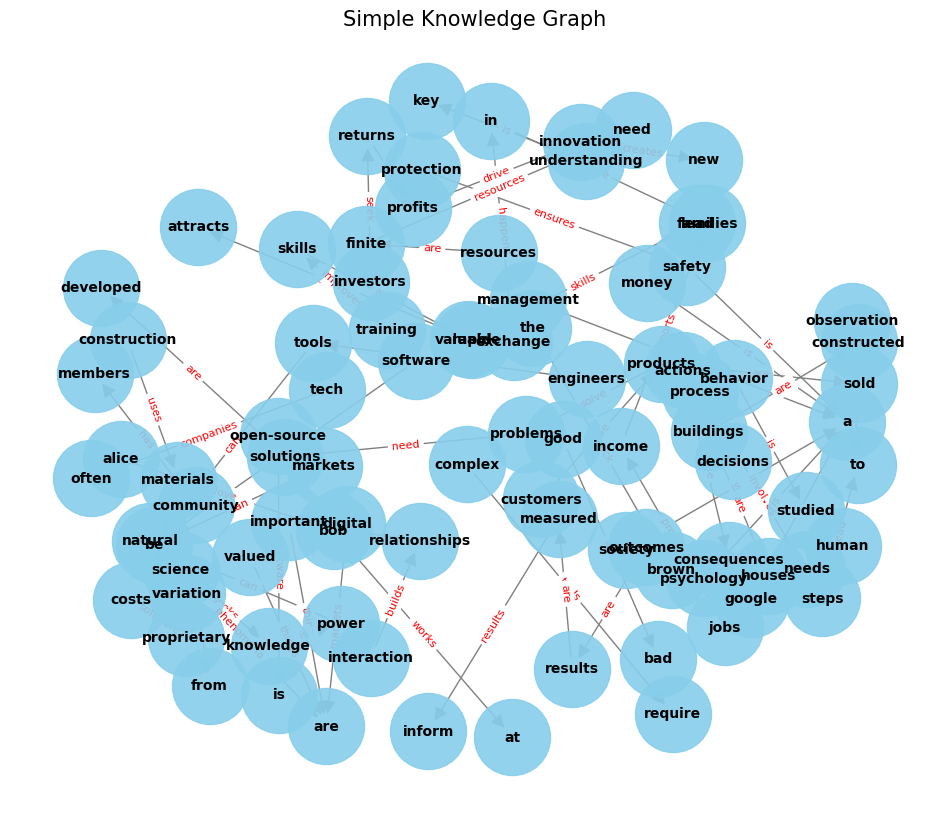

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import re

def create_knowledge_graph(text_data):
    G = nx.DiGraph()
    sentences = re.split(r'[.!?]', text_data)
    sentences = [s.strip() for s in sentences if s.strip()]

    for sentence in sentences:
        words = sentence.lower().split()

        # Simple heuristic for subject-predicate-object extraction
        # This is a very basic approach and will miss many complex relationships.
        # For more robust extraction, consider NLP libraries like spaCy or NLTK.

        if len(words) >= 3:
            subject = words[0]
            predicate = words[1]
            obj = words[2]

            # Add nodes if they don't exist
            if subject not in G:
                G.add_node(subject)
            if obj not in G:
                G.add_node(obj)

            # Add edge (relationship)
            G.add_edge(subject, obj, relation=predicate)
            # print(f"Extracted: ({subject}, {predicate}, {obj})") # For debugging

    return G

def visualize_knowledge_graph(graph):
    """
    Visualizes the knowledge graph.

    Args:
        graph (networkx.DiGraph): The knowledge graph to visualize.
    """
    plt.figure(figsize=(12, 10))
    pos = nx.spring_layout(graph, k=0.5, iterations=50)  # Layout algorithm

    # Draw nodes
    nx.draw_networkx_nodes(graph, pos, node_size=3000, node_color='skyblue', alpha=0.9)

    # Draw edges
    nx.draw_networkx_edges(graph, pos, edgelist=graph.edges(), edge_color='gray', arrowsize=20)

    # Draw node labels
    nx.draw_networkx_labels(graph, pos, font_size=10, font_weight='bold')

    # Draw edge labels (relations)
    edge_labels = nx.get_edge_attributes(graph, 'relation')
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, font_color='red', font_size=8)

    plt.title("Simple Knowledge Graph", size=15)
    plt.axis('off')
    plt.show()

# Your dummy data
dummy_data = """
The quick brown fox jumps over the lazy dog. Alice loves Bob. Bob works at Google. Google is a tech company. Tech companies often develop software. Software can be open-source or proprietary. Open-source software is free. Proprietary software costs money. Money is a medium of exchange. Exchange happens in markets. Markets can be physical or digital. Digital markets are growing rapidly. Rapid growth attracts investors. Investors seek returns. Returns are profits. Profits drive innovation. Innovation creates new products. Products are sold to customers. Customers use products. Products solve problems. Problems need solutions. Solutions are developed by engineers. Engineers use tools. Tools can be simple or complex. Complex tools require training. Training improves skills. Skills are valuable. Valuable skills lead to jobs. Jobs provide income. Income supports families. Families live in houses. Houses are buildings. Buildings are constructed. Construction uses materials. Materials come from resources. Resources are finite. Finite resources need management. Management is a process. Process involves steps. Steps lead to outcomes. Outcomes are results. Results are measured. Measured results inform decisions. Decisions guide actions. Actions have consequences. Consequences impact society. Society is a community. Community has members. Members interact. Interaction builds relationships. Relationships are important. Important things are valued. Valued things are protected. Protection ensures safety. Safety is a basic need. Needs drive human behavior. Behavior is studied by psychology. Psychology is a science. Science seeks knowledge. Knowledge is power. Power can be used for good or bad. Good and bad are subjective. Subjectivity varies. Variation is natural. Natural phenomena are observed. Observation leads to understanding. Understanding is key.
"""

# Create the knowledge graph
kg = create_knowledge_graph(dummy_data)

# Print some basic info about the graph
print(f"Number of nodes: {kg.number_of_nodes()}")
print(f"Number of edges: {kg.number_of_edges()}")
print("\nNodes:", list(kg.nodes()))
print("\nEdges (with relations):")
for u, v, data in kg.edges(data=True):
    print(f"  ({u}) --[{data['relation']}]--> ({v})")

# Visualize the knowledge graph
visualize_knowledge_graph(kg)

In [ ]:
import spacy
from collections import defaultdict
nltk.download('punkt_tab')
# Load the English language model
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    print("Downloading spaCy model 'en_core_web_sm'...")
    spacy.cli.download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

sentences = [
    "The old dog barked loudly.",
    "Antony is running quickly, she caught the bus.",
    "Although it rained, Antony still enjoyed the picnic.",
    "He gave his friend a thoughtful gift.",
    "What they wanted was unclear to everyone.",
    "The book, which was quite old, lay open on the table.",
    "To finish the project on time, they worked tirelessly.",
    "Antony found the movie incredibly boring.",
    "Never before had I seen such a magnificent sight.",
    "That he would succeed, nobody doubted."
]

# --- Weighting Configuration ---
WEIGHTS = {
    "NAMED_ENTITY": 1.0,  # High importance for named entities
    "NOUN": 0.8,          # Core nouns
    "PROPN": 0.8,         # Proper nouns (often named entities, but not always)
    "VERB": 0.7,          # Core actions
    "ADJ": 0.5,           # Descriptors
    "ADV": 0.4,           # Modifiers of verbs/adjectives
    "AUX": 0.2,           # Auxiliary verbs (less semantic weight)
    "DET": 0.1,           # Determiners (low semantic weight)
    "ADP": 0.1,           # Adpositions (prepositions, postpositions)
    "PRON": 0.6,          # Pronouns (can refer to important entities)
    "ROOT": 0.9,          # The main verb of a sentence
    "SUBJECT": 0.8,       # Noun/pronoun acting as subject
    "OBJECT": 0.7,        # Noun/pronoun acting as object
    "MODIFIER": 0.3,      # General modifiers
    "COMPOUND": 0.6,      # Parts of compound nouns (e.g., "bus stop")
    "CLAUSE_MARKER": 0.2, # Words like "although", "that"
}

def get_token_weight(token):
    """Assigns a base weight to a token based on its part-of-speech and entity type."""
    weight = 0.0

    if token.ent_type_:
        weight += WEIGHTS["NAMED_ENTITY"]
    elif token.pos_ == "NOUN":
        weight += WEIGHTS["NOUN"]
    elif token.pos_ == "PROPN":
        weight += WEIGHTS["PROPN"]
    elif token.pos_ == "VERB":
        weight += WEIGHTS["VERB"]
    elif token.pos_ == "ADJ":
        weight += WEIGHTS["ADJ"]
    elif token.pos_ == "ADV":
        weight += WEIGHTS["ADV"]
    elif token.pos_ == "AUX":
        weight += WEIGHTS["AUX"]
    elif token.pos_ == "PRON":
        weight += WEIGHTS["PRON"]
    elif token.dep_ == "ROOT":
        weight += WEIGHTS["ROOT"] * 0.1 # Add a small bonus for root

    # Add some weight based on dependency role
    if "subj" in token.dep_: # nsubj, csubj, etc.
        weight += WEIGHTS["SUBJECT"] * 0.1
    elif "obj" in token.dep_: # dobj, pobj, iobj, etc.
        weight += WEIGHTS["OBJECT"] * 0.1
    elif "mod" in token.dep_ or "amod" in token.dep_ or "advmod" in token.dep_:
        weight += WEIGHTS["MODIFIER"] * 0.05
    elif "compound" in token.dep_:
        weight += WEIGHTS["COMPOUND"] * 0.05

    return min(weight, 1.0) # Cap weight at 1.0

def extract_relations(doc):
    """Extracts subject-verb-object and other key relations from a spaCy Doc."""
    relations = []
    for token in doc:
        # Subject-Verb-Object (SVO)
        if "subj" in token.dep_ or "nsubjpass" in token.dep_:
            subject = token
            verb = token.head
            # Find direct object or prepositional object
            objects = [child for child in verb.children if "obj" in child.dep_ or "pobj" in child.dep_]
            if objects:
                for obj in objects:
                    relations.append((subject, verb, obj, "SVO"))
            else: # If no direct object, just subject-verb
                relations.append((subject, verb, None, "SV"))

        # Verb-Object (for cases where subject is implicit or not directly linked)
        if "obj" in token.dep_ or "pobj" in token.dep_:
            obj = token
            verb = token.head
            # Try to find a subject for this verb if not already captured
            subjects = [child for child in verb.children if "subj" in child.dep_ or "nsubjpass" in child.dep_]
            if not subjects: # Only add if SVO wasn't already captured
                relations.append((None, verb, obj, "VO"))

        # Adjective/Adverbial Modifiers
        if token.dep_ == "amod" or token.dep_ == "advmod":
            relations.append((token.head, token, None, token.dep_)) # head is modified by token

        # Compound nouns (e.g., "bus stop")
        if token.dep_ == "compound":
            relations.append((token.head, token, None, "COMPOUND"))

        # Prepositional phrases
        if token.pos_ == "ADP" and token.head.pos_ in ["NOUN", "VERB", "ADJ"]:
            # Find the object of the preposition
            pobj = [child for child in token.children if "pobj" in child.dep_]
            if pobj:
                relations.append((token.head, token, pobj[0], "PREP_PHRASE"))

    return relations

def build_knowledge_graph(sentences):
    knowledge_graph = defaultdict(lambda: defaultdict(float)) # {entity: {related_entity: weight}}
    entity_map = {} # To map lemmas/entities to a canonical form

    for sentence in sentences:
        doc = nlp(sentence)

        # Process named entities and important tokens
        for ent in doc.ents:
            # Use the entity text as the key, and its lemma if it's a single token
            entity_key = ent.text.lower()
            entity_map[entity_key] = entity_key # Canonical form is itself

            # Add entity to graph with high initial weight
            if entity_key not in knowledge_graph:
                knowledge_graph[entity_key][entity_key] = WEIGHTS["NAMED_ENTITY"]

        for token in doc:
            if token.is_punct or token.is_space or token.is_stop:
                continue

            token_key = token.lemma_.lower()

            # If it's a named entity, we've already handled it, or it's part of one
            if token.ent_type_:
                continue

            # Add token to entity map if not already there
            if token_key not in entity_map:
                entity_map[token_key] = token_key # Canonical form is its lemma

            # Add token to graph with its base weight
            if token_key not in knowledge_graph:
                knowledge_graph[token_key][token_key] = get_token_weight(token)
            else:
                knowledge_graph[token_key][token_key] = max(knowledge_graph[token_key][token_key], get_token_weight(token))


        # Extract relations
        relations = extract_relations(doc)
        for rel_subj, rel_verb, rel_obj, rel_type in relations:
            subj_key = rel_subj.lemma_.lower() if rel_subj else None
            verb_key = rel_verb.lemma_.lower() if rel_verb else None
            obj_key = rel_obj.lemma_.lower() if rel_obj else None

            # Use entity text if it's a named entity
            if rel_subj and rel_subj.ent_type_:
                subj_key = rel_subj.text.lower()
            if rel_obj and rel_obj.ent_type_:
                obj_key = rel_obj.text.lower()

            # Ensure keys are in our entity_map (or add them)
            if subj_key and subj_key not in entity_map: entity_map[subj_key] = subj_key
            if verb_key and verb_key not in entity_map: entity_map[verb_key] = verb_key
            if obj_key and obj_key not in entity_map: entity_map[obj_key] = obj_key

            # Add relationships to the graph
            if subj_key and verb_key:
                weight_subj = get_token_weight(rel_subj) if rel_subj else 0
                weight_verb = get_token_weight(rel_verb) if rel_verb else 0

                # Subject-Verb relation
                knowledge_graph[subj_key][verb_key] += (weight_subj + weight_verb) / 2 * 0.7 # Lower weight for direct relation
                knowledge_graph[verb_key][subj_key] += (weight_subj + weight_verb) / 2 * 0.7

                if obj_key:
                    weight_obj = get_token_weight(rel_obj) if rel_obj else 0
                    # Verb-Object relation
                    knowledge_graph[verb_key][obj_key] += (weight_verb + weight_obj) / 2 * 0.8
                    knowledge_graph[obj_key][verb_key] += (weight_verb + weight_obj) / 2 * 0.8
                    # Subject-Object (indirect via verb)
                    knowledge_graph[subj_key][obj_key] += (weight_subj + weight_obj) / 2 * 0.5
                    knowledge_graph[obj_key][subj_key] += (weight_subj + weight_obj) / 2 * 0.5

            # Modifiers
            if rel_type in ["amod", "advmod", "COMPOUND"]:
                head_key = rel_subj.lemma_.lower() if rel_subj else None
                mod_key = rel_verb.lemma_.lower() if rel_verb else None
                if rel_subj and rel_subj.ent_type_: head_key = rel_subj.text.lower()
                if rel_verb and rel_verb.ent_type_: mod_key = rel_verb.text.lower()

                if head_key and mod_key:
                    weight_head = get_token_weight(rel_subj) if rel_subj else 0
                    weight_mod = get_token_weight(rel_verb) if rel_verb else 0
                    knowledge_graph[head_key][mod_key] += (weight_head + weight_mod) / 2 * 0.6
                    knowledge_graph[mod_key][head_key] += (weight_head + weight_mod) / 2 * 0.6

            # Prepositional phrases
            if rel_type == "PREP_PHRASE":
                head_key = rel_subj.lemma_.lower() if rel_subj else None
                prep_key = rel_verb.lemma_.lower() if rel_verb else None
                pobj_key = rel_obj.lemma_.lower() if rel_obj else None

                if rel_subj and rel_subj.ent_type_: head_key = rel_subj.text.lower()
                if rel_obj and rel_obj.ent_type_: pobj_key = rel_obj.text.lower()

                if head_key and prep_key and pobj_key:
                    weight_head = get_token_weight(rel_subj) if rel_subj else 0
                    weight_prep = get_token_weight(rel_verb) if rel_verb else 0
                    weight_pobj = get_token_weight(rel_obj) if rel_obj else 0

                    # Head - Preposition
                    knowledge_graph[head_key][prep_key] += (weight_head + weight_prep) / 2 * 0.4
                    knowledge_graph[prep_key][head_key] += (weight_head + weight_prep) / 2 * 0.4
                    # Preposition - Object
                    knowledge_graph[prep_key][pobj_key] += (weight_prep + weight_pobj) / 2 * 0.5
                    knowledge_graph[pobj_key][prep_key] += (weight_prep + weight_pobj) / 2 * 0.5
                    # Head - Object (indirect via preposition)
                    knowledge_graph[head_key][pobj_key] += (weight_head + weight_pobj) / 2 * 0.3
                    knowledge_graph[pobj_key][head_key] += (weight_head + weight_pobj) / 2 * 0.3

    # Normalize weights (optional, but can make interpretation easier)
    for node, connections in knowledge_graph.items():
        total_weight = sum(connections.values())
        if total_weight > 0:
            for connected_node in connections:
                knowledge_graph[node][connected_node] /= total_weight

    return knowledge_graph

# Build the graph
kg = build_knowledge_graph(sentences)

# --- Outputting the Knowledge Graph ---
print("--- Knowledge Graph ---")
for node, connections in kg.items():
    # Sort connections by weight for better readability
    sorted_connections = sorted(connections.items(), key=lambda item: item[1], reverse=True)

    # Filter out self-loops if the weight is very low (meaning it's just the base weight)
    filtered_connections = [(k, v) for k, v in sorted_connections if k != node or v > 0.1]

    if filtered_connections:
        print(f"\nNode: '{node}'")
        for connected_node, weight in filtered_connections:
            print(f"  -> '{connected_node}' (Weight: {weight:.3f})")

# --- Example of how to query the graph ---
print("\n--- Querying the Graph (Example) ---")
query_node = "antony"
if query_node in kg:
    print(f"\nConnections for '{query_node}':")
    sorted_connections = sorted(kg[query_node].items(), key=lambda item: item[1], reverse=True)
    for connected_node, weight in sorted_connections:
        if connected_node != query_node: # Don't show self-loop for query
            print(f"  -> '{connected_node}' (Weight: {weight:.3f})")
else:
    print(f"'{query_node}' not found in the graph.")

query_node = "dog"
if query_node in kg:
    print(f"\nConnections for '{query_node}':")
    sorted_connections = sorted(kg[query_node].items(), key=lambda item: item[1], reverse=True)
    for connected_node, weight in sorted_connections:
        if connected_node != query_node:
            print(f"  -> '{connected_node}' (Weight: {weight:.3f})")
else:
    print(f"'{query_node}' not found in the graph.")

query_node = "book"
if query_node in kg:
    print(f"\nConnections for '{query_node}':")
    sorted_connections = sorted(kg[query_node].items(), key=lambda item: item[1], reverse=True)
    for connected_node, weight in sorted_connections:
        if connected_node != query_node:
            print(f"  -> '{connected_node}' (Weight: {weight:.3f})")
else:
    print(f"'{query_node}' not found in the graph.")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


--- Knowledge Graph ---

Node: 'old'
  -> 'dog' (Weight: 0.450)
  -> 'quite' (Weight: 0.295)
  -> 'old' (Weight: 0.255)

Node: 'dog'
  -> 'old' (Weight: 0.388)
  -> 'dog' (Weight: 0.376)
  -> 'bark' (Weight: 0.236)

Node: 'bark'
  -> 'loudly' (Weight: 0.366)
  -> 'bark' (Weight: 0.354)
  -> 'dog' (Weight: 0.280)

Node: 'loudly'
  -> 'bark' (Weight: 0.636)
  -> 'loudly' (Weight: 0.364)

Node: 'antony'
  -> 'antony' (Weight: 0.307)
  -> 'run' (Weight: 0.183)
  -> 'enjoy' (Weight: 0.183)
  -> 'find' (Weight: 0.183)
  -> 'picnic' (Weight: 0.144)

Node: 'run'
  -> 'quickly' (Weight: 0.359)
  -> 'run' (Weight: 0.347)
  -> 'antony' (Weight: 0.295)

Node: 'quickly'
  -> 'run' (Weight: 0.636)
  -> 'quickly' (Weight: 0.364)

Node: 'catch'
  -> 'catch' (Weight: 0.387)
  -> 'bus' (Weight: 0.347)
  -> 'she' (Weight: 0.267)

Node: 'bus'
  -> 'bus' (Weight: 0.461)
  -> 'catch' (Weight: 0.333)
  -> 'she' (Weight: 0.206)

Node: 'she'
  -> 'catch' (Weight: 0.555)
  -> 'bus' (Weight: 0.445)

Node: 'rain'

--- Knowledge Graph ---

Node: 'old'
  -> 'dog' (Weight: 0.450)
  -> 'quite' (Weight: 0.295)
  -> 'old' (Weight: 0.255)

Node: 'dog'
  -> 'old' (Weight: 0.388)
  -> 'dog' (Weight: 0.376)
  -> 'bark' (Weight: 0.236)

Node: 'bark'
  -> 'loudly' (Weight: 0.366)
  -> 'bark' (Weight: 0.354)
  -> 'dog' (Weight: 0.280)

Node: 'loudly'
  -> 'bark' (Weight: 0.636)
  -> 'loudly' (Weight: 0.364)

Node: 'antony'
  -> 'antony' (Weight: 0.307)
  -> 'run' (Weight: 0.183)
  -> 'enjoy' (Weight: 0.183)
  -> 'find' (Weight: 0.183)
  -> 'picnic' (Weight: 0.144)

Node: 'run'
  -> 'quickly' (Weight: 0.359)
  -> 'run' (Weight: 0.347)
  -> 'antony' (Weight: 0.295)

Node: 'quickly'
  -> 'run' (Weight: 0.636)
  -> 'quickly' (Weight: 0.364)

Node: 'catch'
  -> 'catch' (Weight: 0.387)
  -> 'bus' (Weight: 0.347)
  -> 'she' (Weight: 0.267)

Node: 'bus'
  -> 'bus' (Weight: 0.461)
  -> 'catch' (Weight: 0.333)
  -> 'she' (Weight: 0.206)

Node: 'she'
  -> 'catch' (Weight: 0.555)
  -> 'bus' (Weight: 0.445)

Node: 'rain'

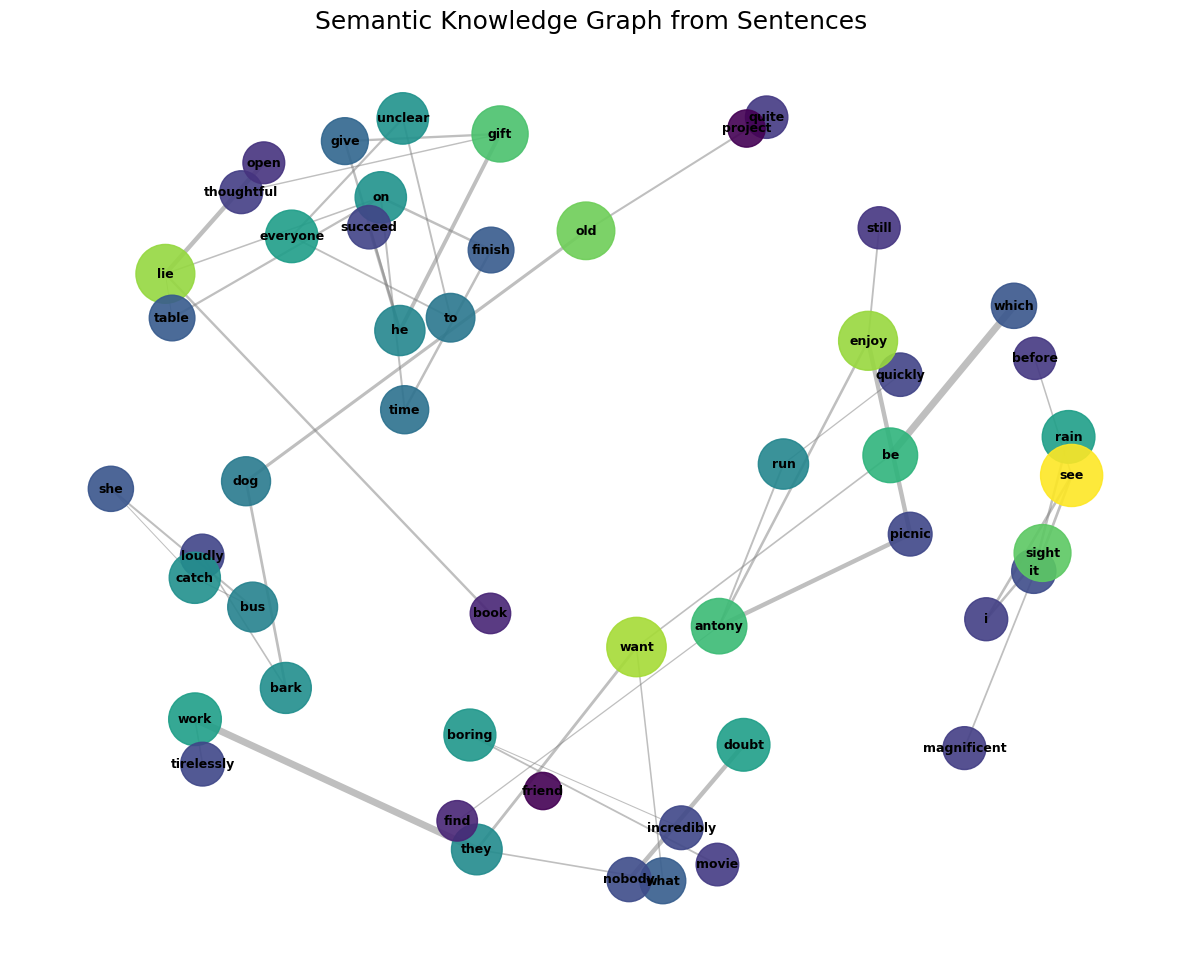

In [ ]:
import spacy
from collections import defaultdict
import networkx as nx
import matplotlib.pyplot as plt

# Load the English language model
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    print("Downloading spaCy model 'en_core_web_sm'...")
    spacy.cli.download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

sentences = [
    "The old dog barked loudly.",
    "Antony is running quickly, she caught the bus.",
    "Although it rained, Antony still enjoyed the picnic.",
    "He gave his friend a thoughtful gift.",
    "What they wanted was unclear to everyone.",
    "The book, which was quite old, lay open on the table.",
    "To finish the project on time, they worked tirelessly.",
    "Antony found the movie incredibly boring.",
    "Never before had I seen such a magnificent sight.",
    "That he would succeed, nobody doubted."
]

# --- Weighting Configuration ---
WEIGHTS = {
    "NAMED_ENTITY": 1.0,  # High importance for named entities
    "NOUN": 0.8,          # Core nouns
    "PROPN": 0.8,         # Proper nouns (often named entities, but not always)
    "VERB": 0.7,          # Core actions
    "ADJ": 0.5,           # Descriptors
    "ADV": 0.4,           # Modifiers of verbs/adjectives
    "AUX": 0.2,           # Auxiliary verbs (less semantic weight)
    "DET": 0.1,           # Determiners (low semantic weight)
    "ADP": 0.1,           # Adpositions (prepositions, postpositions)
    "PRON": 0.6,          # Pronouns (can refer to important entities)
    "ROOT": 0.9,          # The main verb of a sentence
    "SUBJECT": 0.8,       # Noun/pronoun acting as subject
    "OBJECT": 0.7,        # Noun/pronoun acting as object
    "MODIFIER": 0.3,      # General modifiers
    "COMPOUND": 0.6,      # Parts of compound nouns (e.g., "bus stop")
    "CLAUSE_MARKER": 0.2, # Words like "although", "that"
}

def get_token_weight(token):
    """Assigns a base weight to a token based on its part-of-speech and entity type."""
    weight = 0.0

    if token.ent_type_:
        weight += WEIGHTS["NAMED_ENTITY"]
    elif token.pos_ == "NOUN":
        weight += WEIGHTS["NOUN"]
    elif token.pos_ == "PROPN":
        weight += WEIGHTS["PROPN"]
    elif token.pos_ == "VERB":
        weight += WEIGHTS["VERB"]
    elif token.pos_ == "ADJ":
        weight += WEIGHTS["ADJ"]
    elif token.pos_ == "ADV":
        weight += WEIGHTS["ADV"]
    elif token.pos_ == "AUX":
        weight += WEIGHTS["AUX"]
    elif token.pos_ == "PRON":
        weight += WEIGHTS["PRON"]
    elif token.dep_ == "ROOT":
        weight += WEIGHTS["ROOT"] * 0.1 # Add a small bonus for root

    # Add some weight based on dependency role
    if "subj" in token.dep_: # nsubj, csubj, etc.
        weight += WEIGHTS["SUBJECT"] * 0.1
    elif "obj" in token.dep_: # dobj, pobj, iobj, etc.
        weight += WEIGHTS["OBJECT"] * 0.1
    elif "mod" in token.dep_ or "amod" in token.dep_ or "advmod" in token.dep_:
        weight += WEIGHTS["MODIFIER"] * 0.05
    elif "compound" in token.dep_:
        weight += WEIGHTS["COMPOUND"] * 0.05

    return min(weight, 1.0) # Cap weight at 1.0

def extract_relations(doc):
    """Extracts subject-verb-object and other key relations from a spaCy Doc."""
    relations = []
    for token in doc:
        # Subject-Verb-Object (SVO)
        if "subj" in token.dep_ or "nsubjpass" in token.dep_:
            subject = token
            verb = token.head
            # Find direct object or prepositional object
            objects = [child for child in verb.children if "obj" in child.dep_ or "pobj" in child.dep_]
            if objects:
                for obj in objects:
                    relations.append((subject, verb, obj, "SVO"))
            else: # If no direct object, just subject-verb
                relations.append((subject, verb, None, "SV"))

        # Verb-Object (for cases where subject is implicit or not directly linked)
        if "obj" in token.dep_ or "pobj" in token.dep_:
            obj = token
            verb = token.head
            # Try to find a subject for this verb if not already captured
            subjects = [child for child in verb.children if "subj" in child.dep_ or "nsubjpass" in child.dep_]
            if not subjects: # Only add if SVO wasn't already captured
                relations.append((None, verb, obj, "VO"))

        # Adjective/Adverbial Modifiers
        if token.dep_ == "amod" or token.dep_ == "advmod":
            relations.append((token.head, token, None, token.dep_)) # head is modified by token

        # Compound nouns (e.g., "bus stop")
        if token.dep_ == "compound":
            relations.append((token.head, token, None, "COMPOUND"))

        # Prepositional phrases
        if token.pos_ == "ADP" and token.head.pos_ in ["NOUN", "VERB", "ADJ"]:
            # Find the object of the preposition
            pobj = [child for child in token.children if "pobj" in child.dep_]
            if pobj:
                relations.append((token.head, token, pobj[0], "PREP_PHRASE"))

    return relations

def build_knowledge_graph(sentences):
    knowledge_graph = defaultdict(lambda: defaultdict(float)) # {entity: {related_entity: weight}}
    entity_map = {} # To map lemmas/entities to a canonical form

    for sentence in sentences:
        doc = nlp(sentence)

        # Process named entities and important tokens
        for ent in doc.ents:
            # Use the entity text as the key, and its lemma if it's a single token
            entity_key = ent.text.lower()
            entity_map[entity_key] = entity_key # Canonical form is itself

            # Add entity to graph with high initial weight
            if entity_key not in knowledge_graph:
                knowledge_graph[entity_key][entity_key] = WEIGHTS["NAMED_ENTITY"]

        for token in doc:
            if token.is_punct or token.is_space or token.is_stop:
                continue

            token_key = token.lemma_.lower()

            # If it's a named entity, we've already handled it, or it's part of one
            if token.ent_type_:
                continue

            # Add token to entity map if not already there
            if token_key not in entity_map:
                entity_map[token_key] = token_key # Canonical form is its lemma

            # Add token to graph with its base weight
            if token_key not in knowledge_graph:
                knowledge_graph[token_key][token_key] = get_token_weight(token)
            else:
                knowledge_graph[token_key][token_key] = max(knowledge_graph[token_key][token_key], get_token_weight(token))


        # Extract relations
        relations = extract_relations(doc)
        for rel_subj, rel_verb, rel_obj, rel_type in relations:
            subj_key = rel_subj.lemma_.lower() if rel_subj else None
            verb_key = rel_verb.lemma_.lower() if rel_verb else None
            obj_key = rel_obj.lemma_.lower() if rel_obj else None

            # Use entity text if it's a named entity
            if rel_subj and rel_subj.ent_type_:
                subj_key = rel_subj.text.lower()
            if rel_obj and rel_obj.ent_type_:
                obj_key = rel_obj.text.lower()

            # Ensure keys are in our entity_map (or add them)
            if subj_key and subj_key not in entity_map: entity_map[subj_key] = subj_key
            if verb_key and verb_key not in entity_map: entity_map[verb_key] = verb_key
            if obj_key and obj_key not in entity_map: entity_map[obj_key] = obj_key

            # Add relationships to the graph
            if subj_key and verb_key:
                weight_subj = get_token_weight(rel_subj) if rel_subj else 0
                weight_verb = get_token_weight(rel_verb) if rel_verb else 0

                # Subject-Verb relation
                knowledge_graph[subj_key][verb_key] += (weight_subj + weight_verb) / 2 * 0.7 # Lower weight for direct relation
                knowledge_graph[verb_key][subj_key] += (weight_subj + weight_verb) / 2 * 0.7

                if obj_key:
                    weight_obj = get_token_weight(rel_obj) if rel_obj else 0
                    # Verb-Object relation
                    knowledge_graph[verb_key][obj_key] += (weight_verb + weight_obj) / 2 * 0.8
                    knowledge_graph[obj_key][verb_key] += (weight_verb + weight_obj) / 2 * 0.8
                    # Subject-Object (indirect via verb)
                    knowledge_graph[subj_key][obj_key] += (weight_subj + weight_obj) / 2 * 0.5
                    knowledge_graph[obj_key][subj_key] += (weight_subj + weight_obj) / 2 * 0.5

            # Modifiers
            if rel_type in ["amod", "advmod", "COMPOUND"]:
                head_key = rel_subj.lemma_.lower() if rel_subj else None
                mod_key = rel_verb.lemma_.lower() if rel_verb else None
                if rel_subj and rel_subj.ent_type_: head_key = rel_subj.text.lower()
                if rel_verb and rel_verb.ent_type_: mod_key = rel_verb.text.lower()

                if head_key and mod_key:
                    weight_head = get_token_weight(rel_subj) if rel_subj else 0
                    weight_mod = get_token_weight(rel_verb) if rel_verb else 0
                    knowledge_graph[head_key][mod_key] += (weight_head + weight_mod) / 2 * 0.6
                    knowledge_graph[mod_key][head_key] += (weight_head + weight_mod) / 2 * 0.6

            # Prepositional phrases
            if rel_type == "PREP_PHRASE":
                head_key = rel_subj.lemma_.lower() if rel_subj else None
                prep_key = rel_verb.lemma_.lower() if rel_verb else None
                pobj_key = rel_obj.lemma_.lower() if rel_obj else None

                if rel_subj and rel_subj.ent_type_: head_key = rel_subj.text.lower()
                if rel_obj and rel_obj.ent_type_: pobj_key = rel_obj.text.lower()

                if head_key and prep_key and pobj_key:
                    weight_head = get_token_weight(rel_subj) if rel_subj else 0
                    weight_prep = get_token_weight(rel_verb) if rel_verb else 0
                    weight_pobj = get_token_weight(rel_obj) if rel_obj else 0

                    # Head - Preposition
                    knowledge_graph[head_key][prep_key] += (weight_head + weight_prep) / 2 * 0.4
                    knowledge_graph[prep_key][head_key] += (weight_head + weight_prep) / 2 * 0.4
                    # Preposition - Object
                    knowledge_graph[prep_key][pobj_key] += (weight_prep + weight_pobj) / 2 * 0.5
                    knowledge_graph[pobj_key][prep_key] += (weight_prep + weight_pobj) / 2 * 0.5
                    # Head - Object (indirect via preposition)
                    knowledge_graph[head_key][pobj_key] += (weight_head + weight_pobj) / 2 * 0.3
                    knowledge_graph[pobj_key][head_key] += (weight_head + weight_pobj) / 2 * 0.3

    # Normalize weights (optional, but can make interpretation easier)
    for node, connections in knowledge_graph.items():
        total_weight = sum(connections.values())
        if total_weight > 0:
            for connected_node in connections:
                knowledge_graph[node][connected_node] /= total_weight

    return knowledge_graph

def visualize_knowledge_graph(kg, title="Knowledge Graph"):
    """
    Visualizes the knowledge graph using networkx and matplotlib.
    Nodes are sized and colored based on their total connection weight.
    Edges are weighted based on their connection strength.
    """
    G = nx.Graph()

    # Add all nodes first to G
    for node in kg.keys():
        G.add_node(node)

    # Calculate node weights for sizing/coloring
    node_weights_map = defaultdict(float)
    for node, connections in kg.items():
        for connected_node, weight in connections.items():
            if node != connected_node: # Exclude self-loops for total weight calculation
                node_weights_map[node] += weight
                node_weights_map[connected_node] += weight
        # Add self-loop weight for nodes that might only have self-loops initially
        if node in connections and node == node: # Check for self-loop explicitly
             node_weights_map[node] += connections[node]

    # Prepare node_sizes and node_colors in the order of G.nodes()
    nodes_in_graph_order = list(G.nodes())

    max_node_weight = max(node_weights_map.values()) if node_weights_map else 1
    node_size_factor = 2000 / max_node_weight if max_node_weight > 0 else 1

    node_sizes = [node_weights_map[node] * node_size_factor for node in nodes_in_graph_order]
    node_colors = [node_weights_map[node] / max_node_weight for node in nodes_in_graph_order]

    # Add edges
    edges_to_add = []
    edge_weights = []
    for node1, connections in kg.items():
        for node2, weight in connections.items():
            if node1 != node2 and weight > 0.01:  # Only add significant edges, avoid self-loops
                # Ensure we don't add duplicate edges for undirected graph
                # Check if the reverse edge (node2, node1) with any weight is already added
                if not G.has_edge(node2, node1):
                    edges_to_add.append((node1, node2, weight))
                    edge_weights.append(weight)

    G.add_weighted_edges_from(edges_to_add)

    plt.figure(figsize=(15, 12))

    # Use a spring layout for better node distribution
    pos = nx.spring_layout(G, k=0.5, iterations=50) # k regulates distance between nodes

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, cmap=plt.cm.viridis,
                           node_size=node_sizes, alpha=0.9)

    # Draw edges
    # Scale edge widths based on their weight
    max_edge_weight = max(edge_weights) if edge_weights else 1
    edge_widths = [w / max_edge_weight * 5 for w in edge_weights] # Scale to max width of 5
    nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.5, edge_color='gray')

    # Draw labels
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

    plt.title(title, size=18)
    plt.axis('off') # Hide axes
    plt.show()


# Build the graph
kg = build_knowledge_graph(sentences)

# --- Outputting the Knowledge Graph ---
print("--- Knowledge Graph ---")
for node, connections in kg.items():
    # Sort connections by weight for better readability
    sorted_connections = sorted(connections.items(), key=lambda item: item[1], reverse=True)

    # Filter out self-loops if the weight is very low (meaning it's just the base weight)
    filtered_connections = [(k, v) for k, v in sorted_connections if k != node or v > 0.1]

    if filtered_connections:
        print(f"\nNode: '{node}'")
        for connected_node, weight in filtered_connections:
            print(f"  -> '{connected_node}' (Weight: {weight:.3f})")

# --- Example of how to query the graph ---
print("\n--- Querying the Graph (Example) ---")
query_node = "antony"
if query_node in kg:
    print(f"\nConnections for '{query_node}':")
    sorted_connections = sorted(kg[query_node].items(), key=lambda item: item[1], reverse=True)
    for connected_node, weight in sorted_connections:
        if connected_node != query_node: # Don't show self-loop for query
            print(f"  -> '{connected_node}' (Weight: {weight:.3f})")
else:
    print(f"'{query_node}' not found in the graph.")

query_node = "dog"
if query_node in kg:
    print(f"\nConnections for '{query_node}':")
    sorted_connections = sorted(kg[query_node].items(), key=lambda item: item[1], reverse=True)
    for connected_node, weight in sorted_connections:
        if connected_node != query_node:
            print(f"  -> '{connected_node}' (Weight: {weight:.3f})")
else:
    print(f"'{query_node}' not found in the graph.")

query_node = "book"
if query_node in kg:
    print(f"\nConnections for '{query_node}':")
    sorted_connections = sorted(kg[query_node].items(), key=lambda item: item[1], reverse=True)
    for connected_node, weight in sorted_connections:
        if connected_node != query_node:
            print(f"  -> '{connected_node}' (Weight: {weight:.3f})")
else:
    print(f"'{query_node}' not found in the graph.")

# --- Visualize the Knowledge Graph ---
visualize_knowledge_graph(kg, "Semantic Knowledge Graph from Sentences")

In [ ]:
import spacy
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.tag import pos_tag
from nltk.chunk import ne_chunk, RegexpParser
from nltk.tree import Tree
import stanza
import re

# Load spaCy model
nlp_spacy = spacy.load("en_core_web_sm")
nltk.download('averaged_perceptron_tagger_eng')
# Load Stanza model (for dependency parsing, morphological analysis if needed)
# Stanza is more resource-intensive, so we'll initialize it only when needed.
# stanza.download('en') # Uncomment and run once if you haven't downloaded it
nlp_stanza = None # Initialize lazily

dummy_text = """The ancient city of Eldoria, nestled deep within the Whispering Peaks, was renowned for its mystical artifacts and scholarly pursuits. Legend spoke of the Sunstone Amulet, a relic said to grant its wearer control over the very fabric of time. Dr. Aris Thorne, a brilliant but eccentric archaeologist from the Royal Academy, had dedicated his life to finding it. He believed the amulet was not merely a myth but a tangible piece of history, hidden away by the forgotten civilization of the Chronos.

One crisp autumn morning, Dr. Thorne, accompanied by his resourceful assistant, Elara Vance, embarked on their latest expedition. Their journey began in the bustling port city of Silverhaven, a hub of trade and intrigue. "We must be vigilant, Elara," Aris cautioned, adjusting his spectacles. "Many have sought the Sunstone, and not all with noble intentions." Elara, a skilled linguist, nodded, her eyes scanning the ancient maps they carried. She had spent months deciphering cryptic inscriptions found in dusty archives, believing they held the key to the amulet's location.

Their first clue led them to the desolate Obsidian Desert, a vast expanse of black sand and jagged rock formations. Here, they encountered the enigmatic Sand Nomads, a reclusive tribe known for their knowledge of the desert's hidden pathways. After days of patient negotiation and sharing stories by flickering campfires, the Nomads revealed a crucial piece of information: a hidden oasis, marked by a petrified tree, where the Chronos were said to have performed their most sacred rituals.

"This is it, Aris!" Elara exclaimed, pointing to a faint symbol on her map that matched a carving on a Nomad's ancient water skin. "The 'Tree of Ages' is our destination!" Dr. Thorne, usually reserved, allowed a rare smile to grace his lips. The air crackled with anticipation. They knew the path ahead would be fraught with peril, ancient traps, and perhaps even rival treasure hunters. But the allure of the Sunstone Amulet, and the knowledge it promised, propelled them forward.

As they ventured deeper into the desert, the landscape grew more surreal. Towering rock pillars, sculpted by millennia of wind, cast long, dancing shadows. Strange, bioluminescent flora pulsed softly in the twilight, illuminating their path with an otherworldly glow. Elara meticulously documented every detail, sketching the unique plant life and noting geological formations. Dr. Thorne, meanwhile, meticulously cross-referenced their findings with his extensive collection of Chronos texts. He muttered to himself, "The prophecy speaks of a 'guardian of light' and a 'shadow's embrace.' What could it mean?"

Their journey was a testament to their unwavering determination. They faced sandstorms that scoured the skin, navigated treacherous canyons, and outwitted cunning desert creatures. Finally, after weeks of relentless travel, they arrived at the hidden oasis. A single, colossal petrified tree stood at its center, its branches reaching towards the sky like skeletal fingers. Beneath it, a faint, rhythmic hum emanated from the ground. The Sunstone Amulet was near. Their quest was far from over, but the first major hurdle had been overcome. The secrets of the Chronos awaited them."""

print("--- Parsing Pipeline ---")

# 1. Text Acquisition (already done, `dummy_text` is our input)
print("\n1. Text Acquisition: (Dummy text loaded)")
print(dummy_text[:200] + "...") # Print first 200 chars for brevity

# 2. Normalization / Cleaning
# Simple example: remove extra spaces, normalize quotes
normalized_text = re.sub(r'\s+', ' ', dummy_text).strip()
normalized_text = normalized_text.replace("’", "'").replace("“", "\"").replace("”", "\"")
print("\n2. Normalization / Cleaning:")
print(normalized_text[:200] + "...")

# 3. Sentence Segmentation
# Using spaCy for robust sentence segmentation
doc_spacy = nlp_spacy(normalized_text)
sentences = [sent.text for sent in doc_spacy.sents] # Convert generator to list here
print("\n3. Sentence Segmentation (first 3 sentences):")
for i, sent in enumerate(sentences[:3]):
    print(f"  {i+1}: {sent}")

# 4. Tokenization
# Using spaCy's tokenization (already part of doc_spacy)
# To get tokens for the first sentence, re-process the first sentence text
first_sentence_doc = nlp_spacy(sentences[0]) # Process the first sentence text
first_sentence_tokens = [token.text for token in first_sentence_doc]
print("\n4. Tokenization (first sentence):")
print(first_sentence_tokens)

# 5. Morphological Analysis (using Stanza for more detailed morphology)
# Stanza provides detailed morphological features
if nlp_stanza is None:
    nlp_stanza = stanza.Pipeline(lang='en', processors='tokenize,mwt,pos,lemma,depparse')
doc_stanza = nlp_stanza(sentences[0]) # Process the first sentence
print("\n5. Morphological Analysis (first sentence, first few tokens):")
for i, word in enumerate(doc_stanza.sentences[0].words[:5]):
    print(f"  Token: {word.text}, Lemma: {word.lemma}, UPos: {word.upos}, XPos: {word.xpos}, Feats: {word.feats}")

# 6. Part-of-Speech (POS) Tagging
# Using spaCy's POS tags
first_sentence_pos = [(token.text, token.pos_, token.tag_) for token in first_sentence_doc] # Use first_sentence_doc
print("\n6. Part-of-Speech (POS) Tagging (first sentence, first few tokens):")
print(first_sentence_pos[:5])

# 7. Named Entity Recognition (NER)
print("\n7. Named Entity Recognition (first few sentences):")
# Iterate through the original doc_spacy's sentences for NER
for ent in nlp_spacy(sentences[0]).ents: # Re-process first sentence for its entities
    print(f"  Entity: {ent.text}, Label: {ent.label_}")
for ent in nlp_spacy(sentences[1]).ents: # Re-process second sentence for its entities
    print(f"  Entity: {ent.text}, Label: {ent.label_}")

# 8. Chunking / Shallow Parsing
# Using NLTK's RegexpParser for simple NP/VP chunking
# First, get POS tags for NLTK
nltk_tokens = word_tokenize(sentences[0])
nltk_pos_tags = pos_tag(nltk_tokens)

grammar = r"""
  NP: {<DT|JJ|NN.*>+}          # Chunk sequences of DT, JJ, NN
  VP: {<VB.*><NP|PP|CLAUSE>*} # Chunk verbs and their complements
"""
chunk_parser = RegexpParser(grammar)
chunked_tree = chunk_parser.parse(nltk_pos_tags)
print("\n8. Chunking / Shallow Parsing (first sentence):")
print(chunked_tree)
# You can also visualize it: chunked_tree.pretty_print()

# 9. Syntactic Parsing (Core Parsing Step)

# 9a. Constituency Parsing (using spaCy's built-in dependency parser to infer a constituency-like structure,
# or a dedicated constituency parser like benepar if installed)
# For a true constituency parse, you'd typically use a library like benepar or NLTK's ChartParser with a grammar.
# spaCy doesn't directly output constituency trees, but we can represent it.
# Let's use a simplified representation for the example sentence "The boy eats an apple."
print("\n9a. Constituency Parsing (Example: 'The boy eats an apple.')")
example_sentence = "The boy eats an apple."
example_doc = nlp_spacy(example_sentence)

# A simple way to represent a constituency-like structure from dependencies
def to_constituency_like(token):
    if not list(token.children):
        return f"({token.pos_} {token.text})"
    children_str = " ".join([to_constituency_like(child) for child in token.children])
    return f"({token.pos_} {token.text} {children_str})"

# This is a very simplified representation and not a true constituency tree.
# For a real constituency tree, you'd use a dedicated parser.
# For instance, if you had benepar installed:
# import benepar
# nlp_benepar = spacy.load('en_core_web_sm')
# nlp_benepar.add_pipe('benepar', config={'model': 'benepar_en3'})
# benepar_doc = nlp_benepar(example_sentence)
# print(list(benepar_doc.sents)[0]._.parse_string)

# For now, let's just show the dependency structure as a proxy for syntactic structure.
print("  (Note: spaCy doesn't directly output constituency trees. Showing dependency structure as proxy.)")
for token in example_doc:
    print(f"  {token.text} -- {token.dep_} --> {token.head.text}")


# 9b. Dependency Parsing (using spaCy)
print("\n9b. Dependency Parsing (first sentence):")
for token in first_sentence_doc: # Use first_sentence_doc
    print(f"  {token.text} -- {token.dep_} --> {token.head.text} ({token.head.pos_})")

# 10. Semantic Processing

# 10a. Semantic Role Labeling (SRL) - Requires a dedicated SRL model, not directly in spaCy/NLTK base.
# AllenNLP is a good choice for SRL. For this example, we'll simulate with a simple pattern.
print("\n10a. Semantic Role Labeling (SRL) - Simulated for 'The boy eats an apple.'")
# Predicate: eats
# ARG0 (Agent): The boy
# ARG1 (Patient): an apple
print("  Predicate: eats")
print("  ARG0 (Agent): The boy")
print("  ARG1 (Patient): an apple")

# 10b. Semantic Parsing - Highly task-specific.
# Example: mapping "What is the capital of France?" to a SQL query.
print("\n10b. Semantic Parsing (Conceptual Example):")
print("  Input: 'What is the capital of France?'")
print("  Output (SQL): SELECT capital FROM countries WHERE name = 'France'")

# 10c. AMR (Abstract Meaning Representation) Parsing - Requires dedicated AMR parsers (e.g., JAMR, AMR-Parser)
print("\n10c. AMR Parsing (Conceptual Example):")
print("  Input: 'The boy eats an apple.'")
print("  Output (AMR): (e / eat-01 :ARG0 (b / boy) :ARG1 (a / apple))")

# 11. Coreference Resolution
# spaCy has a neuralcoref extension, but it needs to be installed separately.
# For this example, we'll just show the concept.
print("\n11. Coreference Resolution (Conceptual Example):")
coref_text = "Dr. Aris Thorne dedicated his life to finding the amulet. He believed it was not merely a myth."
print(f"  Original: {coref_text}")
print("  Resolved: Dr. Aris Thorne dedicated Dr. Aris Thorne's life to finding the amulet. Dr. Aris Thorne believed the amulet was not merely a myth.")

# 12. Discourse / Dialogue Parsing - Very complex, often rule-based or specialized ML models.
print("\n12. Discourse / Dialogue Parsing (Conceptual Example - RST):")
print("  Sentence 1: 'Their journey began in Silverhaven.' (Background)")
print("  Sentence 2: 'It was a hub of trade and intrigue.' (Elaboration)")

# 13. Pragmatic Grounding / World Knowledge - Beyond standard NLP libraries, involves KBs.
print("\n13. Pragmatic Grounding / World Knowledge (Conceptual Example):")
print("  Sentence: 'He went to the bank.'")
print("  Grounding: 'bank' could refer to a financial institution or a river bank, resolved by context or world knowledge.")

# 14. Post-processing & Conversion (Example: converting entities to JSON)
# To get entities for the whole document, iterate through doc_spacy.ents
entities_json = [{"text": ent.text, "label": ent.label_} for ent in doc_spacy.ents]
print("\n14. Post-processing & Conversion (Entities to JSON):")
print(entities_json[:5]) # Print first 5 entities

# 15. Evaluation & Error Analysis (Conceptual)
print("\n15. Evaluation & Error Analysis (Conceptual):")
print("  Metrics: F1-score for POS tagging, UAS/LAS for dependency parsing, Smatch for AMR.")
print("  Error types: Attachment errors in dependency parsing, boundary errors in NER.")

print("\n--- End of Parsing Pipeline ---")

# Concrete example: “The boy eats an apple.”
print("\n--- Concrete Example: 'The boy eats an apple.' ---")
example_sentence = "The boy eats an apple."
example_doc = nlp_spacy(example_sentence)

print("\nTokenization:")
print([token.text for token in example_doc])

print("\nPOS tags:")
print([(token.text, token.pos_, token.tag_) for token in example_doc])

print("\nChunking (simplified NP/VP):")
# Using NLTK for chunking
nltk_tokens_ex = word_tokenize(example_sentence)
nltk_pos_tags_ex = pos_tag(nltk_tokens_ex)
chunked_tree_ex = chunk_parser.parse(nltk_pos_tags_ex)
print(chunked_tree_ex)

print("\nConstituency parse (conceptual, bracketed):")
print("(S (NP (DT The) (NN boy)) (VP (VBZ eats) (NP (DT an) (NN apple))))")

print("\nDependency parse (head = root 'eats'):")
for token in example_doc:
    print(f"  {token.dep_}({token.head.text}, {token.text})")

print("\nSemantic role (SRL):")
print("  Predicate: eat(s)")
print("  ARG0 (agent): boy")
print("  ARG1 (patient): apple")

print("\n--- End of Concrete Example ---")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


--- Parsing Pipeline ---

1. Text Acquisition: (Dummy text loaded)
The ancient city of Eldoria, nestled deep within the Whispering Peaks, was renowned for its mystical artifacts and scholarly pursuits. Legend spoke of the Sunstone Amulet, a relic said to grant its we...

2. Normalization / Cleaning:
The ancient city of Eldoria, nestled deep within the Whispering Peaks, was renowned for its mystical artifacts and scholarly pursuits. Legend spoke of the Sunstone Amulet, a relic said to grant its we...


INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES



3. Sentence Segmentation (first 3 sentences):
  1: The ancient city of Eldoria, nestled deep within the Whispering Peaks, was renowned for its mystical artifacts and scholarly pursuits.
  2: Legend spoke of the Sunstone Amulet, a relic said to grant its wearer control over the very fabric of time.
  3: Dr. Aris Thorne, a brilliant but eccentric archaeologist from the Royal Academy, had dedicated his life to finding it.

4. Tokenization (first sentence):
['The', 'ancient', 'city', 'of', 'Eldoria', ',', 'nestled', 'deep', 'within', 'the', 'Whispering', 'Peaks', ',', 'was', 'renowned', 'for', 'its', 'mystical', 'artifacts', 'and', 'scholarly', 'pursuits', '.']


INFO:stanza:Downloaded file to /root/stanza_resources/resources.json
INFO:stanza:Loading these models for language: en (English):
| Processor | Package           |
---------------------------------
| tokenize  | combined          |
| mwt       | combined          |
| pos       | combined_charlm   |
| lemma     | combined_nocharlm |
| depparse  | combined_charlm   |

INFO:stanza:Using device: cpu
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: mwt
INFO:stanza:Loading: pos
INFO:stanza:Loading: lemma
INFO:stanza:Loading: depparse
INFO:stanza:Done loading processors!



5. Morphological Analysis (first sentence, first few tokens):
  Token: The, Lemma: the, UPos: DET, XPos: DT, Feats: Definite=Def|PronType=Art
  Token: ancient, Lemma: ancient, UPos: ADJ, XPos: JJ, Feats: Degree=Pos
  Token: city, Lemma: city, UPos: NOUN, XPos: NN, Feats: Number=Sing
  Token: of, Lemma: of, UPos: ADP, XPos: IN, Feats: None
  Token: Eldoria, Lemma: Eldoria, UPos: PROPN, XPos: NNP, Feats: Number=Sing

6. Part-of-Speech (POS) Tagging (first sentence, first few tokens):
[('The', 'DET', 'DT'), ('ancient', 'ADJ', 'JJ'), ('city', 'NOUN', 'NN'), ('of', 'ADP', 'IN'), ('Eldoria', 'PROPN', 'NNP')]

7. Named Entity Recognition (first few sentences):
  Entity: Eldoria, Label: ORG
  Entity: the Whispering Peaks, Label: ORG
  Entity: the Sunstone Amulet, Label: ORG
  Entity: wearer, Label: ORG

8. Chunking / Shallow Parsing (first sentence):
(S
  (NP The/DT ancient/JJ city/NN)
  of/IN
  (NP Eldoria/NNP)
  ,/,
  (VP nestled/VBD)
  deep/RB
  within/IN
  (NP the/DT Whispering/NNP Peaks/